# Political Answer Clarity Classification

The goal of this work is to predict the clarity of politician responses to journalist questions into three categories: *Clear Reply*, *Ambivalent*, and *Clear Non-Reply*.

**Dataset:** [ailsntua/QEvasion](https://huggingface.co/datasets/ailsntua/QEvasion) (Hugging Face)    
**Models:** TF-IDF + Logistic Regression, Word2Vec + Logistic Regression  
**Evaluation:** Accuracy, Precision, Recall, F1-Score

## Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm
from itertools import product
from collections import Counter
import scipy.sparse

!pip install gdown
!pip install gensim
import gensim.downloader

from datasets import load_dataset
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

SEED = 1

## Load Dataset

In [2]:
# Load the dataset HuggingFace
dataset = load_dataset("ailsntua/QEvasion")

In [3]:
print(f"Type of variables of the dataset: {type(dataset)}")
dataset

Type of variables of the dataset: <class 'datasets.dataset_dict.DatasetDict'>


DatasetDict({
    train: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 3448
    })
    test: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 308
    })
})

## Exploratory Data Analysis (EDA)

### Sample Inspection  

In [4]:
# Inspect the first train sample
sample = dataset["train"][0]
sample

{'title': "The President's News Conference in Hanoi, Vietnam",
 'date': 'September 10, 2023',
 'president': 'Joseph R. Biden',
 'url': 'https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-hanoi-vietnam-0',
 'question_order': 1,
 'interview_question': 'Q. Of the Biden administration. And accused the United States of containing China while pushing for diplomatic talks.How would you respond to that? And do you think President Xi is being sincere about getting the relationship back on track as he bans Apple in China?',
 'interview_answer': "Well, look, first of all, theI am sincere about getting the relationship right. And one of the things that is going on now is, China is beginning to change some of the rules of the game, in terms of trade and other issues.And so one of the things we talked about, for example, is that they're now talking about making sure that no Chineseno one in the Chinese Government can use a Western cell phone. Those kinds of things.And so, reall

In [5]:
print(f"Type of samples of the dataset: {type(sample)}")
print(f"Keys of sample-dicts of the dataset: {sample.keys()}")

Type of samples of the dataset: <class 'dict'>
Keys of sample-dicts of the dataset: dict_keys(['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'])


In [6]:
title = sample['title']
president = sample['president']
print(f"Our first training sample has the title '{title}' and concerns president '{president}'.")

Our first training sample has the title 'The President's News Conference in Hanoi, Vietnam' and concerns president 'Joseph R. Biden'.


### Dataset Overview

In [7]:
# Convert to pandas DataFrames
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

# Display first 3 samples of train set
train_df.head(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,85,None,None,None,False,False,False,0,Clear Reply,Explicit
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,85,None,None,None,False,False,False,1,Ambivalent,General
2,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,85,None,None,None,False,False,False,2,Ambivalent,Partial/half-answer


In [8]:
# Display first 3 samples of test set
test_df.head(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
0,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,5,"Q. What about the redline, sir?","Well, the world has made it clear that these t...",None,None,Inquiring about the status or information reg...,None,Dodging,General,Dodging,False,False,True,0,Ambivalent,
1,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,2,Q. Will you invite them to the White House to ...,I think that anytime and anyplace that they ar...,None,None,Will you invite them to the White House to neg...,None,Deflection,General,General,False,False,False,1,Ambivalent,
2,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,1,"Q. Harsh. Mr. President, Japan has dropped the...",I think that the purpose of the U.N. Security ...,None,None,Why was it necessary for Japan to drop the thr...,None,Explicit,Implicit,Implicit,False,False,False,2,Ambivalent,


In [9]:
# Check train/test shapes
print(f"Shapes: Train: {train_df.shape} | Test: {test_df.shape}")

Shapes: Train: (3448, 20) | Test: (308, 20)


In [10]:
# Dtypes, nulls/missing values
print("Train")
display(pd.concat([train_df.dtypes.rename("dtype"), train_df.isnull().sum().rename("nulls")], axis=1))

print("\nTest")
display(pd.concat([test_df.dtypes.rename("dtype"), test_df.isnull().sum().rename("nulls")], axis=1))

Train


,dtype,nulls
title,object,0
date,object,0
president,object,0
url,object,0
question_order,int64,0
interview_question,object,0
interview_answer,object,0
gpt3.5_summary,object,0
gpt3.5_prediction,object,0
question,object,0



Test


,dtype,nulls
title,object,308
date,object,308
president,object,308
url,object,0
question_order,int64,0
interview_question,object,0
interview_answer,object,0
gpt3.5_summary,object,308
gpt3.5_prediction,object,308
question,object,0


In [11]:
# Duplicates
print(f"Duplicates: Train: {train_df.duplicated().sum()} | Test: {test_df.duplicated().sum()}")

Duplicates: Train: 0 | Test: 0


### Class Distributions

In [12]:
# Class distribution of clarity_label (train set)
label_counts = train_df["clarity_label"].value_counts()
display(pd.DataFrame({
    "count": label_counts,
    "%": (label_counts / len(train_df) * 100).round(2)
}))

,count,%
clarity_label,,
Ambivalent,2040,59.16
Clear Reply,1052,30.51
Clear Non-Reply,356,10.32


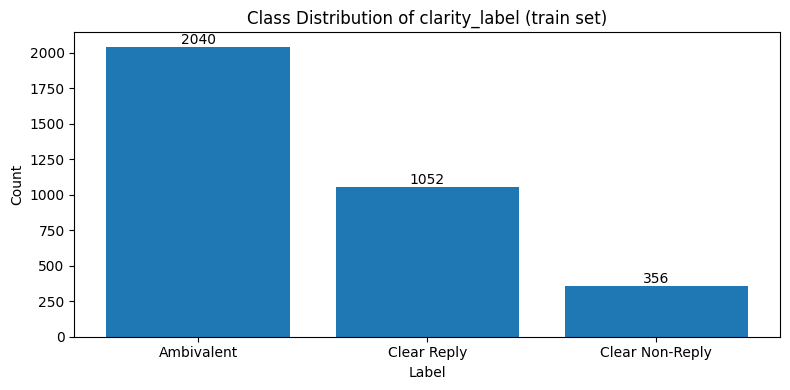

In [13]:
# Class distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(label_counts.index, label_counts.values)
ax.set_title("Class Distribution of clarity_label (train set)")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, v in enumerate(label_counts.values):
  ax.text(i, v + 20, str(v), ha="center")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Class imbalance detected:** Ambivalent dominates with 59%, Clear Reply accounts for 30%, and Clear Non-Reply is rare, represented by 10%. This may affect model performance.

#### Inspect some samples per class

In [14]:
# 'Ambivalent' samples
ambivalent_train_samples = train_df[train_df['clarity_label'] == 'Ambivalent']
ambivalent_train_samples.head(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,85,None,None,None,False,False,False,1,Ambivalent,General
2,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,85,None,None,None,False,False,False,2,Ambivalent,Partial/half-answer
3,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Are you worried about the meeting between Pre...,85,None,None,None,False,False,False,3,Ambivalent,Dodging


In [15]:
# 'Clear Reply' samples
clear_reply_train_samples = train_df[train_df['clarity_label'] == 'Clear Reply']
clear_reply_train_samples.head(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,85,None,None,None,False,False,False,0,Clear Reply,Explicit
4,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,3,"Q. I can imagine. It is evening, I'd like to r...","Well, I hope I get to see Mr. Xi sooner than l...",The question consists of 3 parts:\n1. Is the P...,Question part: 1. Is the President's engagemen...,Is the President's engagement with Asian coun...,85,None,None,None,False,False,False,4,Clear Reply,Explicit
8,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,5,"Q. Well, let me ask you about—you've spent lot...",It's not a wedge issue of the Global South. It...,The question consists of 2 parts:\n\n1. Concer...,Question part 1: Concerns about the lack of co...,Concerns about the lack of communication betw...,85,None,None,None,False,False,True,8,Clear Reply,Explicit


In [16]:
# 'Clear Non-Reply' samples
clear_non_reply_train_samples = train_df[train_df['clarity_label'] == 'Clear Non-Reply']
clear_non_reply_train_samples.head(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
10,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,6,Q. What did you talk about with him?,We talked about what we talked about at the co...,The question consists of 1 part:\n\nPart 1: Wh...,Question part: 1 - What did you talk about wit...,What did you talk about with him?,85,None,None,None,True,False,False,10,Clear Non-Reply,Declining to answer
25,The President's News Conference With President...,"July 13, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,8,"Q. Thank you, Mr. President. We've seen more d...","Well, first of all, they already interfered in...",The question consists of 2 parts:\n\n1. Does t...,Question part: 1 - Does this raise any new con...,Does the firing of the general and the rebell...,85,None,None,None,False,False,False,25,Clear Non-Reply,Claims ignorance
31,The President's News Conference With Prime Min...,"June 22, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,"Q. Thank you, Mr. President. I have a question...",The answer to your first question is: No. You ...,The question consists of 2 parts:\n\n1. Did th...,Question part: 1. Did the comments about Presi...,What is the message to those who say the admin...,85,None,None,None,False,False,False,31,Clear Non-Reply,Clarification


### Text Length Analysis

In [17]:
# Text length statistics (train set)
display(train_df["question"].str.split().str.len().describe().round(2).to_frame())
display(train_df["interview_answer"].str.split().str.len().describe().round(2).to_frame())

,question
count,3448.00
mean,14.46
std,8.83
min,1.00
25%,8.00
50%,12.00
75%,19.00
max,80.00


,interview_answer
count,3448.00
mean,293.57
std,301.54
min,1.00
25%,56.00
50%,207.00
75%,440.00
max,2117.00


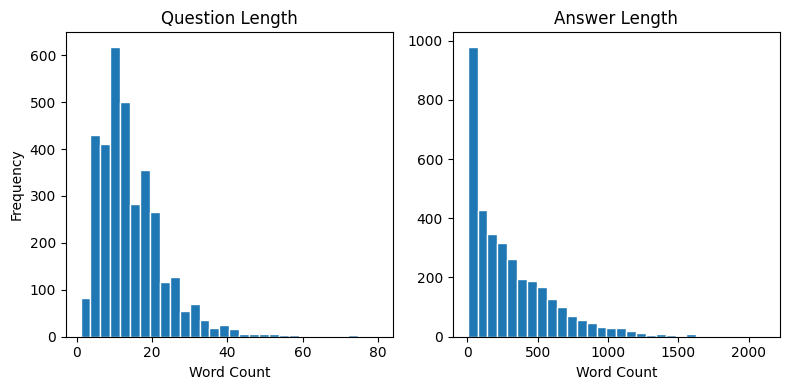

In [18]:
# Word count distribution
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].hist(train_df["question"].str.split().str.len(), bins=30, edgecolor="white")
axes[0].set_title("Question Length")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")

axes[1].hist(train_df["interview_answer"].str.split().str.len(), bins=30, edgecolor="white")
axes[1].set_title("Answer Length")
axes[1].set_xlabel("Word Count")

plt.tight_layout()
plt.savefig("text_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Questions** are short and consistent (5–25 words), roughly normal distribution. **Answers** are heavily right-skewed, most are short but some exceed 1000 words.

In [19]:
# Answer length per class for: do longer answers correlate with clarity? (train set)
ans_len = train_df["interview_answer"].str.split().str.len()
display(ans_len.groupby(train_df["clarity_label"]).describe().round(2))

,count,mean,std,min,25%,50%,75%,max
clarity_label,,,,,,,,
Ambivalent,2040.0,331.86,319.53,1.0,82.75,243.5,491.75,2117.0
Clear Non-Reply,356.0,137.81,217.39,1.0,12.00,39.5,179.25,1407.0
Clear Reply,1052.0,272.04,269.54,1.0,57.75,194.0,415.25,1592.0


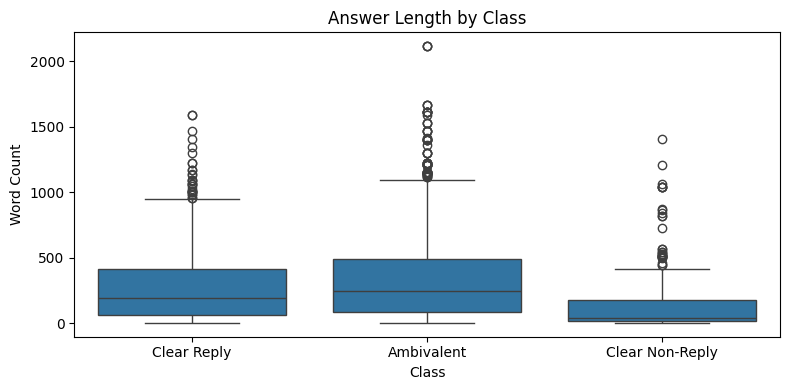

In [20]:
# Answer length per class boxplot
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=train_df["clarity_label"], y=ans_len, ax=ax)
ax.set_title("Answer Length by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Word Count")
plt.tight_layout()
plt.show()

**Ambivalent** answers tend to be longest, while **Clear Non-Reply** answers are the shortest, suggesting politicians who avoid questions do it briefly.

### President Distribution

In [21]:
# Inspect president column
president_column = train_df["president"]
display(president_column.describe().to_frame())

,president
count,3448
unique,4
top,Donald J. Trump
freq,1325


In [22]:
# Unique values
print(president_column.unique())

['Joseph R. Biden' 'Donald J. Trump' 'Barack Obama' 'George W. Bush']


In [23]:
# Column distribution
pres_counts = president_column.value_counts()
display(pres_counts.to_frame())

,count
president,
Donald J. Trump,1325
Barack Obama,1010
George W. Bush,714
Joseph R. Biden,399


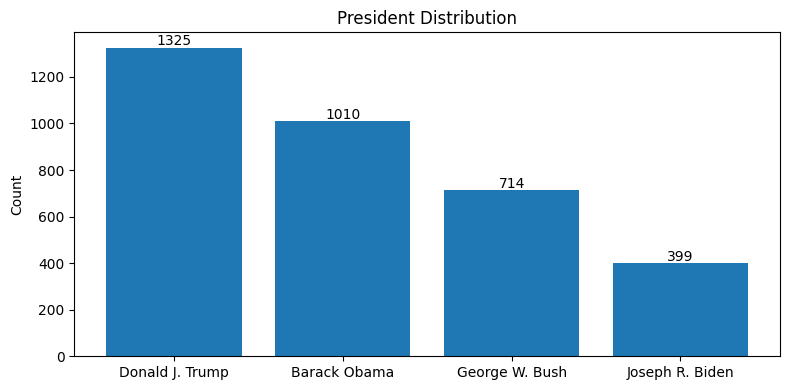

In [24]:
# President distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(pres_counts.index, pres_counts.values)
ax.set_title("President Distribution")
ax.set_ylabel("Count")
for i, v in enumerate(pres_counts.values):
  ax.text(i, v + 10, str(v), ha="center")
plt.tight_layout()
plt.savefig("president_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Trump** dominates the dataset (38%), which may introduce bias toward his speaking style.

In [25]:
# President vs clarity label
pres_clarity = train_df.pivot_table(index="president", columns="clarity_label", aggfunc="size")
display(pres_clarity)

clarity_label,Ambivalent,Clear Non-Reply,Clear Reply
president,,,
Barack Obama,688,96,226
Donald J. Trump,737,156,432
George W. Bush,407,62,245
Joseph R. Biden,208,42,149


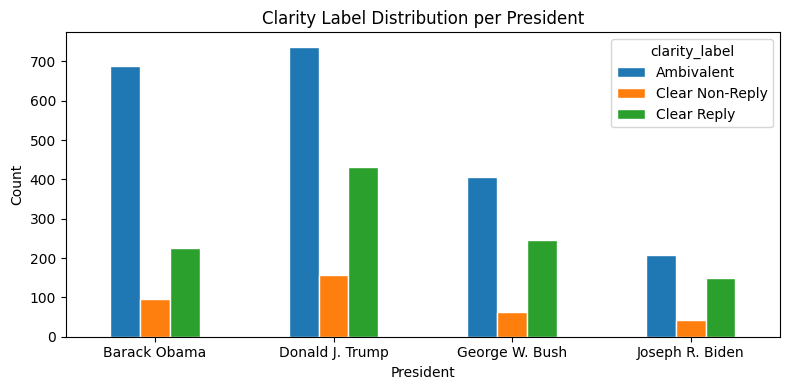

In [27]:
# President vs clarity label plot
pres_clarity.plot(kind="bar", figsize=(8, 4), edgecolor="white")
plt.title("Clarity Label Distribution per President")
plt.xlabel("President")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("class_distribution_per_president.png", dpi=150, bbox_inches="tight")
plt.show()

All presidents follow the same pattern: **Ambivalent** dominates across the board, confirming the class imbalance is not president-specific. In all cases, **Clear Reply** ranks second and **Clear Non-Reply** is the least frequent. Same imbalance pattern across all presidents like the one detected previously. Since all presidents exhibit the same class distribution pattern, potentially adding `president` as a feataure is unlikely to improve classification performance (likely because president identity is not a reliable signal for clarity classification, and this probably the reason why all values are None in the test set for president column).

### Word Frequency Analysis

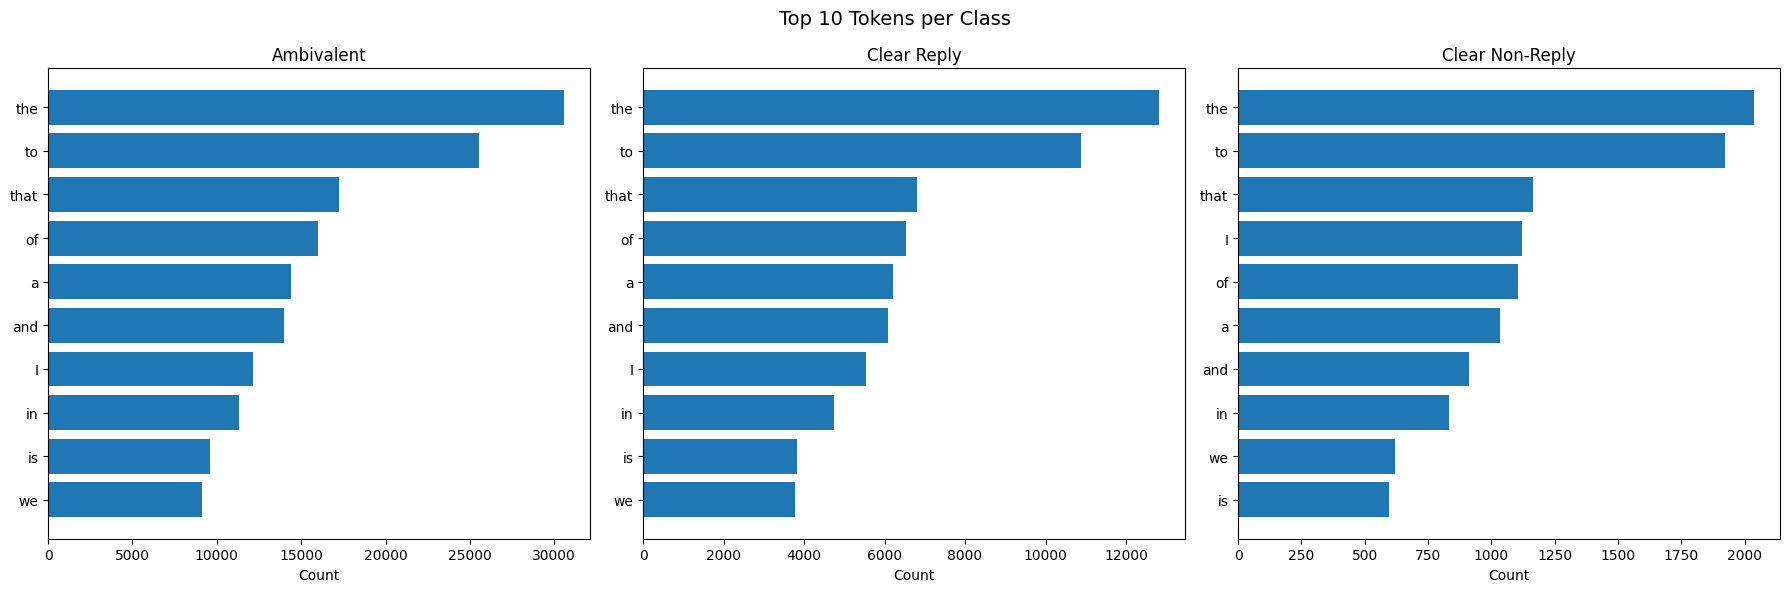

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
labels = ["Ambivalent", "Clear Reply", "Clear Non-Reply"]

for ax, label in zip(axes, labels):
  # Get all words for this class
  texts = " ".join(train_df[train_df["clarity_label"] == label]["interview_answer"].values).split()
  top_words = Counter(texts).most_common(10)
  words, counts = zip(*top_words)

  ax.barh(words[::-1], counts[::-1])
  ax.set_title(label)
  ax.set_xlabel("Count")

plt.suptitle("Top 10 Tokens per Class", fontsize=14)
plt.tight_layout()
plt.savefig("top_tokens_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

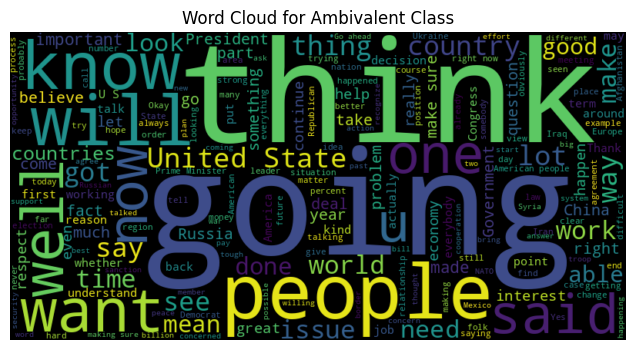

In [31]:
# WordCloud for Ambivalent answers
text = " ".join(train_df[train_df["clarity_label"] == "Ambivalent"]["interview_answer"])
wc = WordCloud(width=800, height=400).generate(text)
plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation="bilinear")
plt.title("Word Cloud for Ambivalent Class")
plt.axis("off")
plt.savefig("wordcloud_ambivalent.png", dpi=150, bbox_inches="tight")
plt.show()

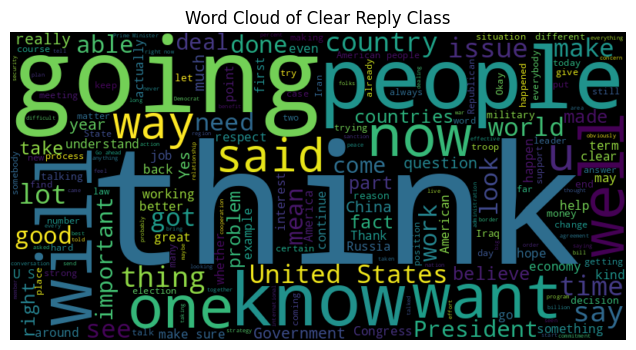

In [32]:
# WordCloud for Clear Reply answers
text = " ".join(train_df[train_df["clarity_label"] == "Clear Reply"]["interview_answer"])
wc = WordCloud(width=800, height=400).generate(text)
plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation="bilinear")
plt.title("Word Cloud of Clear Reply Class")
plt.axis("off")
plt.savefig("wordcloud_clear_reply.png", dpi=150, bbox_inches="tight")
plt.show()

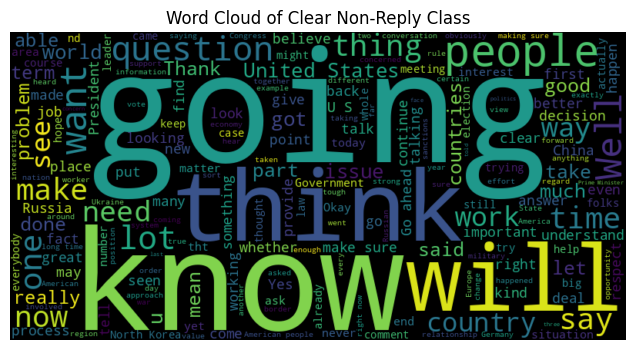

In [33]:
# WordCloud for Clear Non-Reply answers
text = " ".join(train_df[train_df["clarity_label"] == "Clear Non-Reply"]["interview_answer"])
wc = WordCloud(width=800, height=400).generate(text)
plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation="bilinear")
plt.title("Word Cloud of Clear Non-Reply Class")
plt.axis("off")
plt.savefig("wordcloud_clear_nonreply.png", dpi=150, bbox_inches="tight")
plt.show()

## Text Preprocessing

In [34]:
# Simpple preprocessing function to clean the text
def preprocess(text: str) -> str:
  """
  Clean and normalize raw text.

  Args: text as raw input string
  Returns: cleaned lowercase string
  """
  # text = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)  # "theI" -> "the I"
  # text = re.sub(r"^q\.\s*", "", text, flags=re.IGNORECASE)  # remove "Q." at start
  text = text.lower() # lowercase
  text = re.sub(r"[^a-z0-9\s]", " ", text) # remove anything that is not letter, number or space
  text = re.sub(r"\s+", " ", text).strip() # unify multiple spaces into one
  return text

In [35]:
# Test preprocess function
tests = ["Where will go from   here?", "THE PrEsidenT says:'NO ComMent'.", "Multiple     spaces and $"]

for t in tests:
  print(f"In: {t}")
  print(f"Out: {preprocess(t)}\n")

In: Where will go from   here?
Out: where will go from here

In: THE PrEsidenT says:'NO ComMent'.
Out: the president says no comment

In: Multiple     spaces and $
Out: multiple spaces and



In [36]:
# First train sample before preprocessing
print(train_df["question"].iloc[0], "\n")
print(train_df["interview_answer"].iloc[0])

How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks? 

Well, look, first of all, theI am sincere about getting the relationship right. And one of the things that is going on now is, China is beginning to change some of the rules of the game, in terms of trade and other issues.And so one of the things we talked about, for example, is that they're now talking about making sure that no Chineseno one in the Chinese Government can use a Western cell phone. Those kinds of things.And so, really, what this trip was aboutit was less about containing China. I don't want to contain China. I just want to make sure that we have a relationship with China that is on the up and up, squared away, everybody knows what it's all about. And one of the ways you do that is, you make sure that we are talking about the same things.And I think that one of the things we've doneI've tried to do, and I've talked with a number of my staff about this 

In [37]:
# Apply preprocessing to question and interview_answer
for df in [train_df, test_df]:
  df["question"] = df["question"].apply(preprocess)
  df["interview_answer"] = df["interview_answer"].apply(preprocess)

In [38]:
# Verify preprocessing on first train samaple
print(train_df["question"].iloc[0], "\n")
print(train_df["interview_answer"].iloc[0])

how would you respond to the accusation that the united states is containing china while pushing for diplomatic talks 

well look first of all thei am sincere about getting the relationship right and one of the things that is going on now is china is beginning to change some of the rules of the game in terms of trade and other issues and so one of the things we talked about for example is that they re now talking about making sure that no chineseno one in the chinese government can use a western cell phone those kinds of things and so really what this trip was aboutit was less about containing china i don t want to contain china i just want to make sure that we have a relationship with china that is on the up and up squared away everybody knows what it s all about and one of the ways you do that is you make sure that we are talking about the same things and i think that one of the things we ve donei ve tried to do and i ve talked with a number of my staff about this for the last i gues

## Input Construction

In [39]:
# Combine question and answer into a single input by using a separator token
train_df["input"] = train_df["question"] + " [SEP] " + train_df["interview_answer"]
test_df["input"] = test_df["question"]  + " [SEP] " + test_df["interview_answer"]

In [40]:
# Inspect the first processed train input sample (notice [SEP] between question and answer)
print(train_df["input"].iloc[0])

how would you respond to the accusation that the united states is containing china while pushing for diplomatic talks [SEP] well look first of all thei am sincere about getting the relationship right and one of the things that is going on now is china is beginning to change some of the rules of the game in terms of trade and other issues and so one of the things we talked about for example is that they re now talking about making sure that no chineseno one in the chinese government can use a western cell phone those kinds of things and so really what this trip was aboutit was less about containing china i don t want to contain china i just want to make sure that we have a relationship with china that is on the up and up squared away everybody knows what it s all about and one of the ways you do that is you make sure that we are talking about the same things and i think that one of the things we ve donei ve tried to do and i ve talked with a number of my staff about this for the last i 

### Create Splits

In [41]:
# Stratified split of train_df
train_set, val_set = train_test_split(train_df, test_size=0.15, random_state=SEED, stratify=train_df["clarity_label"]) # startify for keeping class proportions equal in both splits

In [42]:
# Confirm stratisfaction preserved original class proportions  in both splits
print(f"train_set: {train_set.shape} | val_set: {val_set.shape}")
print(f"\nClass distribution in train_set: {(train_set["clarity_label"].value_counts(normalize=True)*100).round(2)}")
print(f"\nClass distribution in val_set: {(val_set["clarity_label"].value_counts(normalize=True)*100).round(2)}")

train_set: (2930, 21) | val_set: (518, 21)

Class distribution in train_set: clarity_label
Ambivalent         59.18
Clear Reply        30.51
Clear Non-Reply    10.31
Name: proportion, dtype: float64

Class distribution in val_set: clarity_label
Ambivalent         59.07
Clear Reply        30.50
Clear Non-Reply    10.42
Name: proportion, dtype: float64


In [43]:
# Features and labels
X_train = train_set["input"]
y_train = train_set["clarity_label"]
X_val = val_set["input"]
y_val = val_set["clarity_label"]

# Original test set remains untouched
X_test = test_df["input"]
y_test = test_df["clarity_label"]

## TF-IDF + Logistic Regression

### TF-IDF Representation   

We start with the default `TfidfVectorizer` settings. Hyperparameters such as `max_features` and others will be tuned later.

In [44]:
# TF-IDF vectorization
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

In [45]:
print(f"Before TF-IDF vectorization: Train: {X_train.shape} | Val: {X_val.shape} | Type: {type(X_train)}")
print(f"After TF-IDF vectorization: Train: {X_train_tfidf.shape} | Val: {X_val_tfidf.shape} | Type: {type(X_train_tfidf)}")

Before TF-IDF vectorization: Train: (2930,) | Val: (518,) | Type: <class 'pandas.core.series.Series'>
After TF-IDF vectorization: Train: (2930, 13585) | Val: (518, 13585) | Type: <class 'scipy.sparse._csr.csr_matrix'>


In [46]:
# Inspect first train sample of TF-IDF vector
feature_names = tfidf.get_feature_names_out()
sample_vector = X_train_tfidf[0].toarray()[0]

print(f"Text: {X_train.iloc[0][:100]}...")
print(f"Shape: {sample_vector.shape}")
print("Five non-zero values:\n")

count = 0
for i, score in enumerate(sample_vector):
  if score > 0:
    count += 1
    print(f"{feature_names[i]}: {score:.2f}")
    if count == 5:
      break

Text: what is america doing to help india tackle terrorism that originates from pakistan [SEP] well first ...
Shape: (13585,)
Five non-zero values:

all: 0.10
america: 0.17
doing: 0.14
first: 0.14
from: 0.11


### LR with TF-IDF Representation   

In [47]:
# Train Logistic Regression on TF-IDF feature-representation
lr_tfidf_v0 = LogisticRegression(max_iter=1000, random_state=SEED)
lr_tfidf_v0.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=1)

In [48]:
# Define a custom function for accuracy
def accuracy_count(y_true, y_pred, split) -> None:
  """
  Print number and percentage of correct predictions.

  Args:
    y_true: true labels
    y_pred: predicted labels
    split: whether it  is train or val split
  """
  correct = sum(1 for t, p in zip(y_true, y_pred) if t == p)
  total = len(y_true)
  print(f"{split.capitalize()} Accurracy: {correct}/{total} ({correct/total*100:.2f}%)")

In [49]:
# Evaluate on train set: sanity check for overfitting
y_pred_train_tfidf_v0 = lr_tfidf_v0.predict(X_train_tfidf)
accuracy_count(y_train, y_pred_train_tfidf_v0, "train")

Train Accurracy: 2259/2930 (77.10%)


In [50]:
# Evaluate on val set: real performance (notice the difference between train accuracy and validation accuracy)
y_pred_tfidf_v0 = lr_tfidf_v0.predict(X_val_tfidf)
accuracy_count(y_val, y_pred_tfidf_v0, "Val")

Val Accurracy: 314/518 (60.62%)


In [51]:
# Inspect some predictions
for i in range(5):
  print(f"Input: {val_set["input"].iloc[i][:100]}...")
  print(f"True: {val_set["clarity_label"].iloc[i]}")
  print(f"Predicted: {y_pred_tfidf_v0[i]}\n")

Input: build back better agenda and senators manchin and sinema [SEP] that s all i thought i said we d take...
True: Ambivalent
Predicted: Ambivalent

Input: have you considered that [SEP] well i would certainly consider that i will mandate it if you d like ...
True: Clear Reply
Predicted: Ambivalent

Input: is the program development still ongoing [SEP] he said the testing will not start he said that he s ...
True: Ambivalent
Predicted: Clear Reply

Input: whether the relationship between the two leaders has grown closer [SEP] now let me ask the lastanswe...
True: Clear Reply
Predicted: Ambivalent

Input: are you threatening to veto any legislation that includes funding for the post office [SEP] no not a...
True: Clear Reply
Predicted: Clear Reply



In [52]:
# Classification report with detailed metrics: accuracy, presicion, recall, f1-score
print(classification_report(y_val, y_pred_tfidf_v0))

                 precision    recall  f1-score   support

     Ambivalent       0.62      0.91      0.74       306
Clear Non-Reply       0.38      0.06      0.10        54
    Clear Reply       0.54      0.22      0.31       158

       accuracy                           0.61       518
      macro avg       0.51      0.39      0.38       518
   weighted avg       0.57      0.61      0.54       518



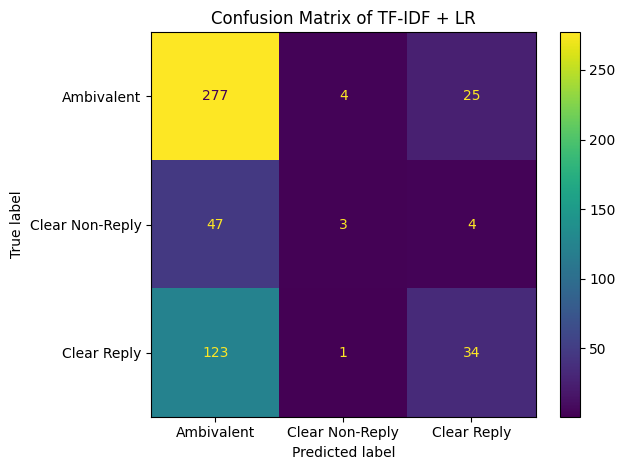

In [53]:
# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_tfidf_v0)
plt.title("Confusion Matrix of TF-IDF + LR")
plt.tight_layout()
plt.savefig("confusion_matrix_v0_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

In [54]:
def plot_learning_curves(model, X_train, y_train, X_val, y_val, title: str) -> None:
  """
  Train model on increasing subsets of training data and plot train vs val F1.

  Args:
    model: sklearn estimator
    X_train/y_train: training data
    X_val/y_val: validation data
    title: plot title
  """
  list_f1_train = []
  list_f1_val = []
  list_sizes = []

  for i in range(1, 11):
    # Take i*10% of training data
    size = int(X_train.shape[0] * i * 0.1)
    X_subset = X_train[:size]
    y_subset = y_train.iloc[:size]

    # Train fresh model on subset
    model.fit(X_subset, y_subset)

    f1_train = f1_score(y_subset, model.predict(X_subset), average="macro")
    f1_val = f1_score(y_val, model.predict(X_val), average="macro")

    list_f1_train.append(f1_train)
    list_f1_val.append(f1_val)
    list_sizes.append(i * 10)

    print(f"{i}/{len(range(1,11))} | Train F1: {f1_train:.2f} | Val F1: {f1_val:.2f} | size: {size}")

  # Plot
  fig, ax = plt.subplots(figsize=(8, 4))
  ax.plot(list_sizes, list_f1_train, label="Train")
  ax.plot(list_sizes, list_f1_val, label="Validation")
  ax.set_title(title)
  ax.set_xlabel("Training Set Percentage Used")
  ax.set_ylabel("Macro F1")
  ax.set_xlim(xmin=0)
  ax.set_ylim(ymin=0)
  ax.legend()
  plt.tight_layout()
  plt.savefig(f"{title}.png", dpi=150, bbox_inches="tight")
  plt.show()

1/10 | Train F1: 0.53 | Val F1: 0.29 | size: 293
2/10 | Train F1: 0.63 | Val F1: 0.27 | size: 586
3/10 | Train F1: 0.70 | Val F1: 0.32 | size: 879
4/10 | Train F1: 0.67 | Val F1: 0.33 | size: 1172
5/10 | Train F1: 0.66 | Val F1: 0.32 | size: 1465
6/10 | Train F1: 0.67 | Val F1: 0.33 | size: 1758
7/10 | Train F1: 0.67 | Val F1: 0.33 | size: 2051
8/10 | Train F1: 0.67 | Val F1: 0.36 | size: 2344
9/10 | Train F1: 0.67 | Val F1: 0.38 | size: 2637
10/10 | Train F1: 0.67 | Val F1: 0.38 | size: 2930


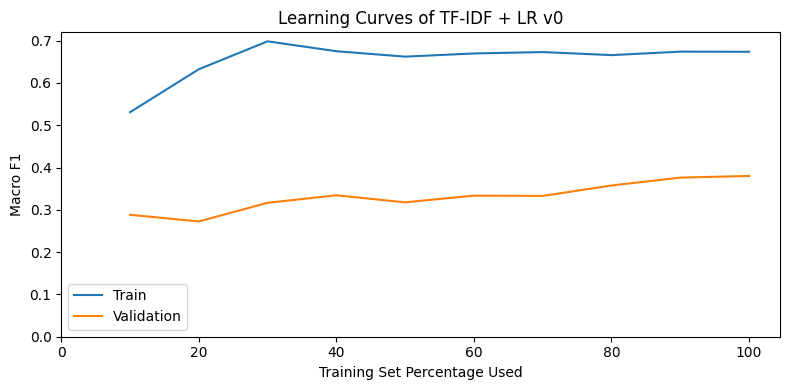

In [55]:
# Learning curves: detect overfitting by comparing train vs val F1 across training sizes (a fresh model is created here as the function retrains from scratch at each subset size)
clf = LogisticRegression(max_iter=1000, random_state=SEED)
plot_learning_curves(clf, X_train_tfidf, y_train, X_val_tfidf, y_val, "Learning Curves of TF-IDF + LR v0")

**TF-IDF + LR (v0):** The model heavily favors **Ambivalent**, missing most of **Clear Reply** and **Clear Non-Reply**. The gap between train accuracy and val accuracy (train accuracy higher tna validation one), raises the question: is the model overfitting?

To investigate, we plot **learning curves** by training on increasing subsets of the training data and evaluating on the fixed validation set at each step. The learning curves confirm **overfitting:** train F1 is significantly higher than validation F1, with the gap persisting across all training sizes, suggesting the model memorizes training patterns rather than learning generalizable features.  

In [56]:
# Save TF-IDF + LR (v0) results
results = []

report_lr_tfidf_v0_dict = classification_report(y_val, y_pred_tfidf_v0, output_dict=True)
results.append({
    "model": "TF-IDF + LR",
    "version": "default",
    "val_accuracy": round(report_lr_tfidf_v0_dict["accuracy"], 2),
    "val_precision": round(report_lr_tfidf_v0_dict["macro avg"]["precision"], 2),
    "val_recall": round(report_lr_tfidf_v0_dict["macro avg"]["recall"], 2),
    "val_f1": round(report_lr_tfidf_v0_dict["macro avg"]["f1-score"], 2)
})

## Word2Vec + Logistic Regression

###  Word2Vec Representation

In [57]:
# # Download Google News Word2Vec vectors
# import gdown

# file_id = '0B7XkCwpI5KDYNlNUTTlSS21pQmM'
# url = f'https://drive.google.com/uc?id={file_id}&resourcekey=0-wjGZdNAUop6WykTtMip30g'
# gdown.download(url, 'GoogleNews-vectors-negative300.bin.gz', quiet=False)

# # Load pretrained Word2Vec
# from gensim.models import KeyedVectors
# w2v_model = KeyedVectors.load_word2vec_format("GoogleNews-vectors-negative300.bin.gz", binary=True)

# Download via gensim
w2v_model = gensim.downloader.load("word2vec-google-news-300")

In [58]:
# Check vocab and vector sizes
print(f"Vocab size: {len(w2v_model)}")
print(f"Vector size: {w2v_model.vector_size}")

Vocab size: 3000000
Vector size: 300


In [59]:
# Test it
test_vector = w2v_model["high"]
print(f"Test vector length: {len(test_vector)}")
print(test_vector)

Test vector length: 300
[ 0.07666016  0.00970459 -0.08007812  0.18164062 -0.02624512 -0.08447266
 -0.00823975 -0.19140625  0.07373047  0.11914062 -0.05297852 -0.15136719
  0.21679688 -0.18652344  0.02661133 -0.17773438 -0.06933594  0.01190186
 -0.07226562 -0.08935547 -0.16113281  0.01324463 -0.10107422  0.1171875
  0.02099609 -0.22167969 -0.1328125   0.04833984  0.08886719 -0.28320312
  0.19433594 -0.17285156  0.3671875  -0.03198242 -0.18652344 -0.10693359
 -0.15136719 -0.12695312  0.10986328  0.11865234  0.20996094 -0.02001953
  0.08105469 -0.02172852 -0.11035156  0.04516602  0.07275391  0.20898438
  0.08154297 -0.03063965  0.14453125  0.04858398 -0.02038574  0.03857422
 -0.02429199 -0.078125   -0.33789062 -0.04760742 -0.07958984 -0.11279297
 -0.02185059  0.0625     -0.25195312 -0.03320312 -0.07128906  0.13671875
 -0.14160156  0.09863281  0.11035156  0.15234375 -0.09277344 -0.13476562
  0.08886719  0.203125   -0.14941406  0.07568359  0.16113281  0.26757812
  0.02746582  0.15527344  0.

In [60]:
# Inspect similar word to high
print(f"Most similar words to 'high': {w2v_model.most_similar('high')}")

Most similar words to 'high': [('low', 0.7421891689300537), ('High', 0.5790752172470093), ('higher', 0.569451630115509), ('highest', 0.5553146004676819), ('ahigh', 0.5219955444335938), ('lower', 0.5140001773834229), ('Low', 0.5026226043701172), ('HIGH', 0.4793128967285156), ('lowest', 0.4690744876861572), ('elevated', 0.46033966541290283)]


In [61]:
# Average Word2Vec vectors per sample
def average_w2v(text: str, verbose=False) -> np.ndarray:
  """
  Average Word2Vec vectors for all words in text.

  Args:
    text: preprocessed input string
    Verbose: enable prints if True

  Returns: 300-dim vector with zeros if no words found
  """
  words = text.split()
  vectors = [w2v_model[w] for w in words if w in w2v_model]
  if verbose:
    print(f"Text: {text}")
    print(f"Shape after w2v model: {[v.shape for v in vectors]}")
    # print(vectors)
  if vectors:
    avg_vector = np.mean(vectors, axis=0)
    if verbose:
      print(f"Shape after averaging: {avg_vector.shape}")
      print(f"First 5 averaged values: {avg_vector[:5]}\n")
    return avg_vector
  return np.zeros(w2v_model.vector_size)

In [62]:
# Test average_w2v func
test_sentences = ["the president said no", "clear reply"]
for s in test_sentences:
  vec = average_w2v(s, verbose=True)

Text: the president said no
Shape after w2v model: [(300,), (300,), (300,), (300,)]
Shape after averaging: (300,)
First 5 averaged values: [ 0.03500366 -0.05267334  0.08996582  0.00656128 -0.04348755]

Text: clear reply
Shape after w2v model: [(300,), (300,)]
Shape after averaging: (300,)
First 5 averaged values: [ 0.02770996  0.00634766 -0.08935547 -0.08129883 -0.00830078]



In [63]:
# Apply average_w2v
X_train_w2v = np.array([average_w2v(text) for text in X_train])
X_val_w2v = np.array([average_w2v(text) for text in X_val])

In [64]:
# Inspect shapes before and after applying embedding representation
print(f"Before Word2Vec: Train: {X_train.shape} | Val: {X_val.shape} | Type: {type(X_train)}")
print(f"After Word2Vec: Train: {X_train_w2v.shape} | Val: {X_val_w2v.shape} | Type: {type(X_train_w2v)}")

Before Word2Vec: Train: (2930,) | Val: (518,) | Type: <class 'pandas.core.series.Series'>
After Word2Vec: Train: (2930, 300) | Val: (518, 300) | Type: <class 'numpy.ndarray'>


In [65]:
# Inspect first train sample of Word2Vec vector
print(f"Text: {X_train.iloc[0][:100]}...")
print(f"Shape: {X_train_w2v[0].shape}")
print(f"First 5 values: {X_train_w2v[0][:5].round((2))}")

Text: what is america doing to help india tackle terrorism that originates from pakistan [SEP] well first ...
Shape: (300,)
First 5 values: [-0.01  0.02  0.05  0.11 -0.11]


Each sample is represented by a single **300-dim vector**, obtained by: (1) splitting the text into words, (2) looking up each word in the W2V model to get its 300-dim vector, (3) averaging all word vectors into one.

### LR with Word2Vec Representation   

In [66]:
# Train Logistic Regression on Word2Vec feature-representation
lr_w2v_v0 = LogisticRegression(max_iter=1000, random_state=SEED)
lr_w2v_v0.fit(X_train_w2v, y_train)

LogisticRegression(max_iter=1000, random_state=1)

In [67]:
# Evaluate on train set: sanity check for overfitting
y_pred_train_w2v_v0 = lr_w2v_v0.predict(X_train_w2v)
accuracy_count(y_train, y_pred_train_w2v_v0, "train")

Train Accurracy: 1827/2930 (62.35%)


In [68]:
# Evaluate on val set: real performance
y_pred_w2v_v0 = lr_w2v_v0.predict(X_val_w2v)
accuracy_count(y_val, y_pred_w2v_v0, "val")

Val Accurracy: 315/518 (60.81%)


In [69]:
# Classification report with detailed metrics: accuracy, presicion, recall, f1-score
print(classification_report(y_val, y_pred_w2v_v0))

                 precision    recall  f1-score   support

     Ambivalent       0.61      0.96      0.75       306
Clear Non-Reply       0.50      0.11      0.18        54
    Clear Reply       0.60      0.09      0.16       158

       accuracy                           0.61       518
      macro avg       0.57      0.39      0.36       518
   weighted avg       0.60      0.61      0.51       518



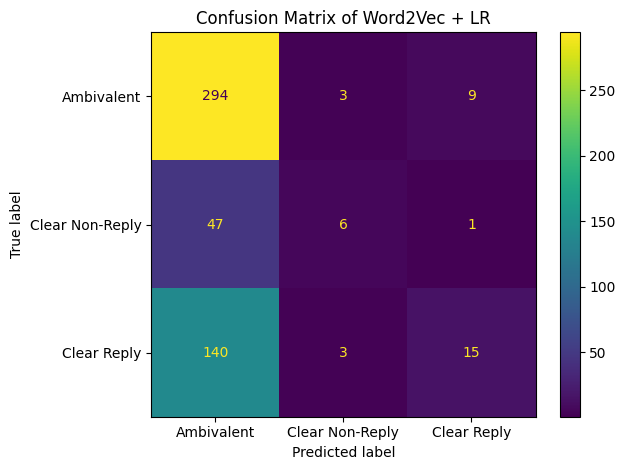

In [70]:
# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_w2v_v0)
plt.title("Confusion Matrix of Word2Vec + LR")
plt.tight_layout()
plt.savefig("confusion_matrix_v0_w2v.png", dpi=150, bbox_inches="tight")
plt.show()

1/10 | Train F1: 0.30 | Val F1: 0.27 | size: 293
2/10 | Train F1: 0.31 | Val F1: 0.27 | size: 586
3/10 | Train F1: 0.33 | Val F1: 0.26 | size: 879
4/10 | Train F1: 0.35 | Val F1: 0.30 | size: 1172
5/10 | Train F1: 0.34 | Val F1: 0.30 | size: 1465
6/10 | Train F1: 0.35 | Val F1: 0.29 | size: 1758
7/10 | Train F1: 0.36 | Val F1: 0.31 | size: 2051
8/10 | Train F1: 0.36 | Val F1: 0.33 | size: 2344
9/10 | Train F1: 0.37 | Val F1: 0.35 | size: 2637
10/10 | Train F1: 0.37 | Val F1: 0.36 | size: 2930


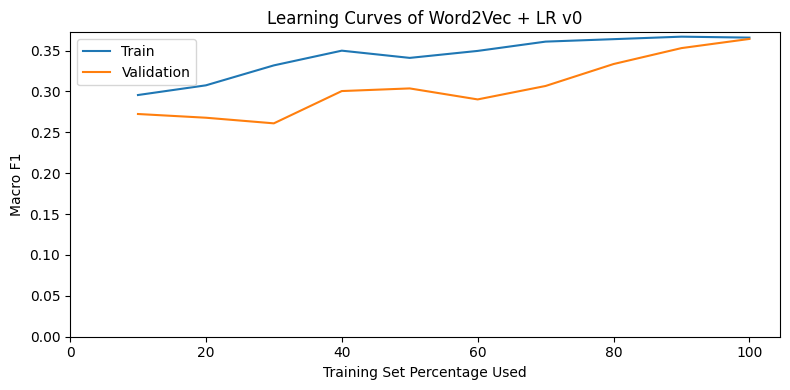

In [71]:
# Learning curves: compare train vs val F1 across training sizes
clf = LogisticRegression(max_iter=1000, random_state=SEED)
plot_learning_curves(clf, X_train_w2v, y_train, X_val_w2v, y_val, "Learning Curves of Word2Vec + LR v0")

**Word2Vec + LR (v0):** Similar to TF-IDF v0, the model predicts **Ambivalent**, almost completely ignoring **Clear Non-Reply** and **Clear Reply**. The learning curves show both curves having very low F1 and rising together with a small gap (underfitting). The averaged vector representation lacks the power to correctly separate the minority classes.

In [72]:
# Save Word2Vec + LR (v0) results
report_lr_w2v_v0_dict = classification_report(y_val, y_pred_w2v_v0, output_dict=True)
results.append({
    "model": "Word2Vec + LR",
    "version": "default",
    "val_accuracy": round(report_lr_w2v_v0_dict["accuracy"], 2),
    "val_precision": round(report_lr_w2v_v0_dict["macro avg"]["precision"], 2),
    "val_recall": round(report_lr_w2v_v0_dict["macro avg"]["recall"], 2),
    "val_f1": round(report_lr_w2v_v0_dict["macro avg"]["f1-score"], 2)
})

In [73]:
# Display results of (v0)
display(pd.DataFrame(results))

,model,version,val_accuracy,val_precision,val_recall,val_f1
0,TF-IDF + LR,default,0.61,0.51,0.39,0.38
1,Word2Vec + LR,default,0.61,0.57,0.39,0.36


## Experiments

Having established baseline models, we now systematically try to improve both of them. Each experiment introduces one targeted change, allowing us to isolate its effect on performance.

### v1: Class Balancing + Representation Tuning   

Both baseline models face class imbalance. We address this with `class_weight="balanced"`. Additionally, we tune some parameters of TF-IDF vectorizer (e.g., `max_features` and `ngram_range`) and also try a different embedding representation (`GloVe`).

#### TF-IDF + LR (v1)   

##### Class Balancing

In [74]:
# v1a (TF-IDF): class balancing with class_weight="balanced"
lr_tfidf_v1a = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_tfidf_v1a.fit(X_train_tfidf, y_train)

# Evaluate on train set
y_pred_train_tfidf_v1a = lr_tfidf_v1a.predict(X_train_tfidf)
accuracy_count(y_train, y_pred_train_tfidf_v1a, "train")

# Evaluate on val set
y_pred_val_tfidf_v1a = lr_tfidf_v1a.predict(X_val_tfidf)
accuracy_count(y_val, y_pred_val_tfidf_v1a, "val")

# Classification report with detailed metrics
print(classification_report(y_val, y_pred_val_tfidf_v1a))

Train Accurracy: 2345/2930 (80.03%)
Val Accurracy: 294/518 (56.76%)
                 precision    recall  f1-score   support

     Ambivalent       0.71      0.60      0.65       306
Clear Non-Reply       0.38      0.61      0.47        54
    Clear Reply       0.45      0.49      0.47       158

       accuracy                           0.57       518
      macro avg       0.51      0.57      0.53       518
   weighted avg       0.59      0.57      0.58       518



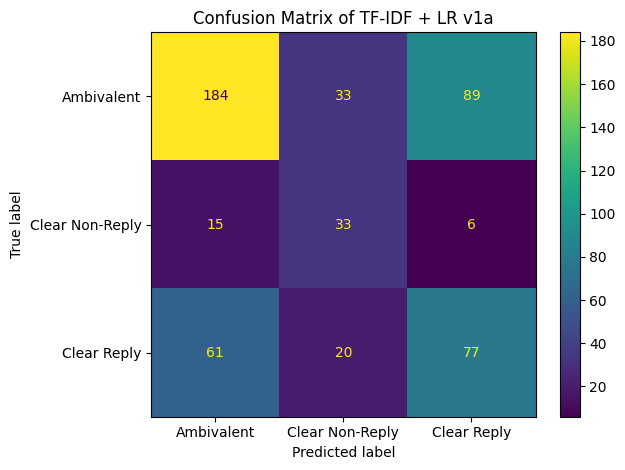

In [75]:
# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_tfidf_v1a)
plt.title("Confusion Matrix of TF-IDF + LR v1a")
plt.tight_layout()
plt.show()

In [76]:
print(f"v0 Val F1: {results[0]['val_f1']}")
print(f"v1a Val F1: {f1_score(y_val, y_pred_val_tfidf_v1a, average="macro"):.3f}")

v0 Val F1: 0.38
v1a Val F1: 0.529


`class_weight="balanced"` alone improves F1, confirming that class imbalance was the dominant problem.

##### Representation Tuning (TF-IDF)  

In [77]:
# Tune max_features: find optimal vocabulary size on top of class balancing
max_features_list = [None, 3000, 5000, 7000, 10000, 12000]
f1_list = []

for max_f in max_features_list:
  tfidf_temp = TfidfVectorizer(max_features=max_f)
  X_tr = tfidf_temp.fit_transform(X_train)
  X_vl = tfidf_temp.transform(X_val)

  lr_temp = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
  lr_temp.fit(X_tr, y_train)

  y_pred_temp = lr_temp.predict(X_vl)
  f1 = f1_score(y_val, y_pred_temp, average="macro")
  f1_list.append(f1)
  print(f"max_features={max_f} → Val F1: {round(f1, 3)}")

best_max_features = max_features_list[np.argmax(f1_list)]
print(f"\nBest max_features: {best_max_features}")

max_features=None → Val F1: 0.529
max_features=3000 → Val F1: 0.523
max_features=5000 → Val F1: 0.518
max_features=7000 → Val F1: 0.533
max_features=10000 → Val F1: 0.528
max_features=12000 → Val F1: 0.528

Best max_features: 7000


In [78]:
# Tune n-grams (try unigrams, bigrams, and trigrams)
ngram_list = [(1,1), (1,2), (1,3)]
f1_ngram_list = []

for ngram in ngram_list:
  tfidf_temp = TfidfVectorizer(max_features=best_max_features, ngram_range=ngram)
  X_tr = tfidf_temp.fit_transform(X_train)
  X_vl = tfidf_temp.transform(X_val)
  lr_temp = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
  lr_temp.fit(X_tr, y_train)
  f1 = f1_score(y_val, lr_temp.predict(X_vl), average="macro")
  f1_ngram_list.append(f1)
  print(f"ngram_range={ngram} → Val F1: {round(f1, 3)}")

best_ngram = ngram_list[np.argmax(f1_ngram_list)]
print(f"\nBest ngram_range: {best_ngram}")
print(f"Vocabulary size with best ngram {best_ngram}: {tfidf_temp.get_feature_names_out().shape[0]}")

ngram_range=(1, 1) → Val F1: 0.533
ngram_range=(1, 2) → Val F1: 0.516
ngram_range=(1, 3) → Val F1: 0.515

Best ngram_range: (1, 1)
Vocabulary size with best ngram (1, 1): 7000


In [79]:
# Dsiplay some samples of unigrams and bigrams
feature_names_ngram = tfidf_temp.get_feature_names_out()

unigrams = [f for f in feature_names_ngram if len(f.split()) == 1][500:505]
bigrams = [f for f in feature_names_ngram if len(f.split()) == 2][500:505]

print("Sample unigrams:", unigrams)
print("Sample bigrams:", bigrams)

Sample unigrams: ['del', 'deliver', 'demand', 'demands', 'democracies']
Sample bigrams: ['chairman kim', 'chance to', 'change and', 'change in', 'change the']


In [80]:
# Tune sublinear_tf + min_df + max_df on top of best_max_features and best_ngram
configs = [
    {"sublinear_tf": False, "min_df": 1, "max_df": 1.0},
    {"sublinear_tf": True, "min_df": 1, "max_df": 1.0},
    {"sublinear_tf": True, "min_df": 2, "max_df": 0.95},
    {"sublinear_tf": True, "min_df": 3, "max_df": 0.90},
]
f1_config_list = []

for cfg in configs:
  tfidf_temp = TfidfVectorizer(max_features=best_max_features, ngram_range=best_ngram, sublinear_tf=cfg["sublinear_tf"], min_df=cfg["min_df"], max_df=cfg["max_df"])
  X_tr = tfidf_temp.fit_transform(X_train)
  X_vl = tfidf_temp.transform(X_val)

  lr_temp = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
  lr_temp.fit(X_tr, y_train)

  f1 = f1_score(y_val, lr_temp.predict(X_vl), average="macro")
  f1_config_list.append(f1)
  print(f"sublinear={cfg['sublinear_tf']}  min_df={cfg['min_df']}  max_df={cfg['max_df']}  →  F1: {f1:.3f}")

best_cfg = configs[np.argmax(f1_config_list)]
print(f"\nBest config: {best_cfg}")

sublinear=False  min_df=1  max_df=1.0  →  F1: 0.533
sublinear=True  min_df=1  max_df=1.0  →  F1: 0.537
sublinear=True  min_df=2  max_df=0.95  →  F1: 0.533
sublinear=True  min_df=3  max_df=0.9  →  F1: 0.533

Best config: {'sublinear_tf': True, 'min_df': 1, 'max_df': 1.0}


In [81]:
# v1 final (TF-IDF): class balancing + representation tuning
tfidf_v1 = TfidfVectorizer(max_features=best_max_features, ngram_range=best_ngram, sublinear_tf=best_cfg["sublinear_tf"], min_df=best_cfg["min_df"], max_df=best_cfg["max_df"])
X_train_tfidf_v1 = tfidf_v1.fit_transform(X_train)
X_val_tfidf_v1 = tfidf_v1.transform(X_val)

# Train Logistic Regression on TF-IDF features (v1)
lr_tfidf_v1 = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_tfidf_v1.fit(X_train_tfidf_v1, y_train)

# Evaluate on train set
y_pred_train_tfidf_v1 = lr_tfidf_v1.predict(X_train_tfidf_v1)
accuracy_count(y_train, y_pred_train_tfidf_v1, "train")

# Evaluate on val set
y_pred_val_tfidf_v1 = lr_tfidf_v1.predict(X_val_tfidf_v1)
accuracy_count(y_val, y_pred_val_tfidf_v1, "val")

# Classification report with detailed metrics
print(classification_report(y_val, y_pred_val_tfidf_v1))

Train Accurracy: 2376/2930 (81.09%)
Val Accurracy: 296/518 (57.14%)
                 precision    recall  f1-score   support

     Ambivalent       0.70      0.62      0.66       306
Clear Non-Reply       0.43      0.63      0.51        54
    Clear Reply       0.43      0.46      0.44       158

       accuracy                           0.57       518
      macro avg       0.52      0.57      0.54       518
   weighted avg       0.59      0.57      0.58       518



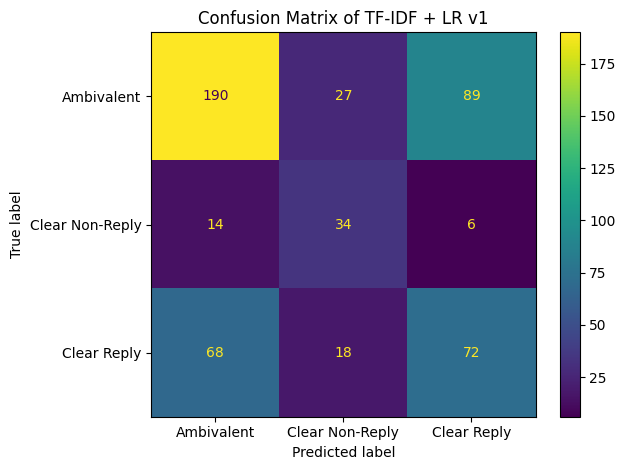

In [82]:
# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_tfidf_v1)
plt.title("Confusion Matrix of TF-IDF + LR v1")
plt.tight_layout()
plt.savefig("confusion_matrix_v1_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

1/10 | Train F1: 0.96 | Val F1: 0.40 | size: 293
2/10 | Train F1: 0.96 | Val F1: 0.43 | size: 586
3/10 | Train F1: 0.92 | Val F1: 0.51 | size: 879
4/10 | Train F1: 0.88 | Val F1: 0.49 | size: 1172
5/10 | Train F1: 0.86 | Val F1: 0.51 | size: 1465
6/10 | Train F1: 0.85 | Val F1: 0.49 | size: 1758
7/10 | Train F1: 0.84 | Val F1: 0.51 | size: 2051
8/10 | Train F1: 0.81 | Val F1: 0.50 | size: 2344
9/10 | Train F1: 0.80 | Val F1: 0.53 | size: 2637
10/10 | Train F1: 0.80 | Val F1: 0.54 | size: 2930


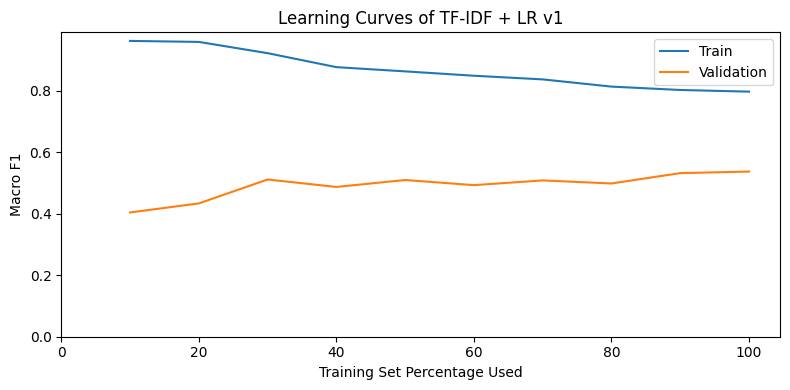

In [83]:
# Learning curves: check if v1 improvements reduced overfitting gap
clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
plot_learning_curves(clf, X_train_tfidf_v1, y_train, X_val_tfidf_v1, y_val, "Learning Curves of TF-IDF + LR v1")

**TF-IDF + LR (v1):** Class balancing dramatically improves minority class coverage of **Clear Non-Reply** and **Clear Reply** that are now meaningfully detected. The learning curves show a converging pattern: train F1 decreases while validation F1 rises, indicating the overfitting gap is closing and the model is generalizing better.

#### Word2Vec + LR (v1)   

##### Class Balancing  

In [84]:
# v1 (Word2Vec): class_weight="balanced" to address class imbalance
lr_w2v_v1 = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_w2v_v1.fit(X_train_w2v, y_train)

# Evaluate on train set
y_pred_train_w2v_v1 = lr_w2v_v1.predict(X_train_w2v)
accuracy_count(y_train, y_pred_train_w2v_v1, "train")

# Evaluate on val set
y_pred_val_w2v_v1 = lr_w2v_v1.predict(X_val_w2v)
accuracy_count(y_val, y_pred_val_w2v_v1, "val")

# Classification report with detailed metrics
print(classification_report(y_val, y_pred_val_w2v_v1))

Train Accurracy: 1658/2930 (56.59%)
Val Accurracy: 284/518 (54.83%)
                 precision    recall  f1-score   support

     Ambivalent       0.71      0.65      0.68       306
Clear Non-Reply       0.28      0.61      0.38        54
    Clear Reply       0.43      0.33      0.37       158

       accuracy                           0.55       518
      macro avg       0.47      0.53      0.48       518
   weighted avg       0.58      0.55      0.56       518



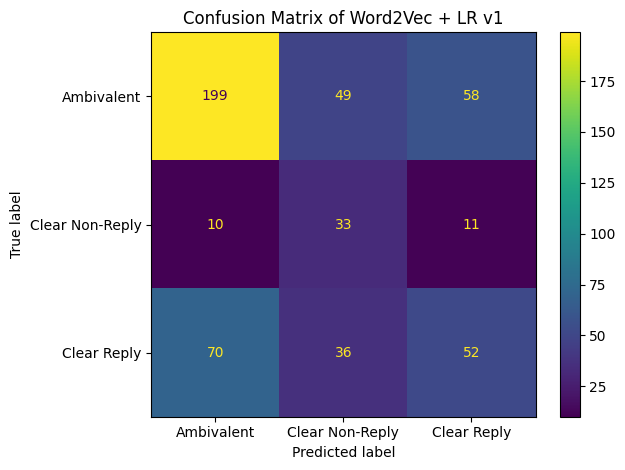

In [85]:
# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_w2v_v1)
plt.title("Confusion Matrix of Word2Vec + LR v1")
plt.tight_layout()
plt.show()

In [86]:
print(f"v0 Val F1: {results[1]['val_f1']}")
print(f"v1a Val F1: {f1_score(y_val, y_pred_val_w2v_v1, average="macro"):.3f}")

v0 Val F1: 0.36
v1a Val F1: 0.479


Similarly to TF-IDF case, `class_weight="balanced"` alone improves F1.

1/10 | Train F1: 0.56 | Val F1: 0.43 | size: 293
2/10 | Train F1: 0.54 | Val F1: 0.45 | size: 586
3/10 | Train F1: 0.53 | Val F1: 0.48 | size: 879
4/10 | Train F1: 0.52 | Val F1: 0.45 | size: 1172
5/10 | Train F1: 0.52 | Val F1: 0.45 | size: 1465
6/10 | Train F1: 0.52 | Val F1: 0.47 | size: 1758
7/10 | Train F1: 0.51 | Val F1: 0.46 | size: 2051
8/10 | Train F1: 0.51 | Val F1: 0.46 | size: 2344
9/10 | Train F1: 0.51 | Val F1: 0.46 | size: 2637
10/10 | Train F1: 0.52 | Val F1: 0.48 | size: 2930


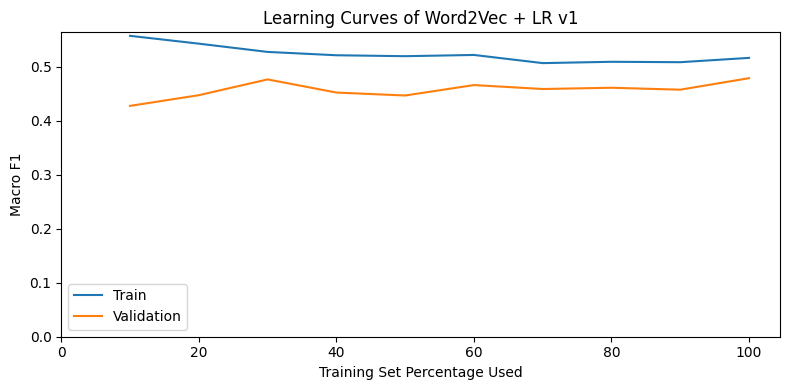

In [87]:
# Learning curves: compare v0 vs v1 performances
clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
plot_learning_curves(clf, X_train_w2v, y_train, X_val_w2v, y_val, "Learning Curves of Word2Vec + LR v1")

**Word2Vec + LR (v1):** Class balancing successfully activates all three classes and they are now detected meaningfully. The learning curves show both curves stable and close together, indicating the underfitting issue is reduced.

##### Representation Tuning (Word2Vec)   

In [88]:
# Check all available models in gensim downloader
print(list(gensim.downloader.info()['models'].keys()))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [89]:
# Load GloVe
glove_model = gensim.downloader.load("glove-wiki-gigaword-300")
print(f"Vocab size: {len(glove_model)}")
print(f"Vector size: {glove_model.vector_size}")

Vocab size: 400000
Vector size: 300


In [90]:
def average_w2v_glove(text: str) -> np.ndarray:
  """
  Average GloVe vectors for all known words in text.

  Args: text: preprocessed string
  Returns: 300-dim averaged vector, zeros if no words found
  """
  words = text.split()
  vectors = [glove_model[w] for w in words if w in glove_model]
  if vectors:
    return np.mean(vectors, axis=0)
  return np.zeros(glove_model.vector_size)

In [91]:
# Build GloVe averaged vectors using the same approach as Google News embedding model
X_train_glove = np.array([average_w2v_glove(t) for t in X_train])
X_val_glove = np.array([average_w2v_glove(t) for t in X_val])

print(f"Shapes: Train: {X_train_glove.shape} | Val: {X_val_glove.shape}")

Shapes: Train: (2930, 300) | Val: (518, 300)


In [92]:
# Representation tuning: compare the two embedding models with class balancing
emb_names = ["Word2Vec (Google News)", "GloVe"]
emb_trains = [X_train_w2v, X_train_glove]
emb_vals = [X_val_w2v, X_val_glove]

f1_emb_list = []

for name, X_tr, X_vl in zip(emb_names, emb_trains, emb_vals):
  lr_temp = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
  lr_temp.fit(X_tr, y_train)
  f1 = f1_score(y_val, lr_temp.predict(X_vl), average="macro")
  f1_emb_list.append(f1)
  print(f"{name} → Val F1: {f1:.3f}")

best_emb_idx = np.argmax(f1_emb_list)
best_emb_name = emb_names[best_emb_idx]

X_train_w2v_v1 = emb_trains[best_emb_idx]
X_val_w2v_v1 = emb_vals[best_emb_idx]

print(f"\nBest embedding: {best_emb_name}")

Word2Vec (Google News) → Val F1: 0.479
GloVe → Val F1: 0.491

Best embedding: GloVe


In [93]:
# Train best performing embedding model with class balancing
lr_w2v_v1 = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_w2v_v1.fit(X_train_w2v_v1, y_train)

# Evaluate on train set
y_pred_train_w2v_v1 = lr_w2v_v1.predict(X_train_w2v_v1)
accuracy_count(y_train, y_pred_train_w2v_v1,"train")

# Evaluate on val set
y_pred_val_w2v_v1 = lr_w2v_v1.predict(X_val_w2v_v1)
accuracy_count(y_val, y_pred_val_w2v_v1, "val")

# Classification report with detailed metrics
print(classification_report(y_val, y_pred_val_w2v_v1))

Train Accurracy: 1669/2930 (56.96%)
Val Accurracy: 278/518 (53.67%)
                 precision    recall  f1-score   support

     Ambivalent       0.68      0.59      0.63       306
Clear Non-Reply       0.33      0.59      0.43        54
    Clear Reply       0.42      0.41      0.42       158

       accuracy                           0.54       518
      macro avg       0.48      0.53      0.49       518
   weighted avg       0.56      0.54      0.54       518



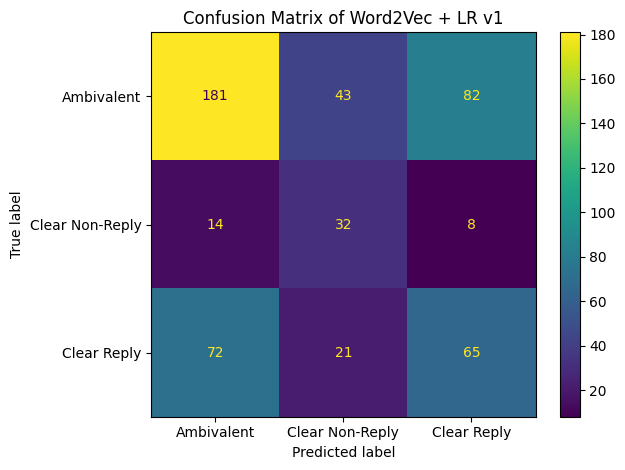

In [94]:
# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_w2v_v1)
plt.title("Confusion Matrix of Word2Vec + LR v1")
plt.tight_layout()
plt.savefig("confusion_matrix_v1_w2v.png", dpi=150, bbox_inches="tight")
plt.show()

1/10 | Train F1: 0.63 | Val F1: 0.45 | size: 293
2/10 | Train F1: 0.61 | Val F1: 0.47 | size: 586
3/10 | Train F1: 0.58 | Val F1: 0.47 | size: 879
4/10 | Train F1: 0.57 | Val F1: 0.47 | size: 1172
5/10 | Train F1: 0.56 | Val F1: 0.47 | size: 1465
6/10 | Train F1: 0.55 | Val F1: 0.48 | size: 1758
7/10 | Train F1: 0.54 | Val F1: 0.48 | size: 2051
8/10 | Train F1: 0.53 | Val F1: 0.47 | size: 2344
9/10 | Train F1: 0.53 | Val F1: 0.47 | size: 2637
10/10 | Train F1: 0.53 | Val F1: 0.49 | size: 2930


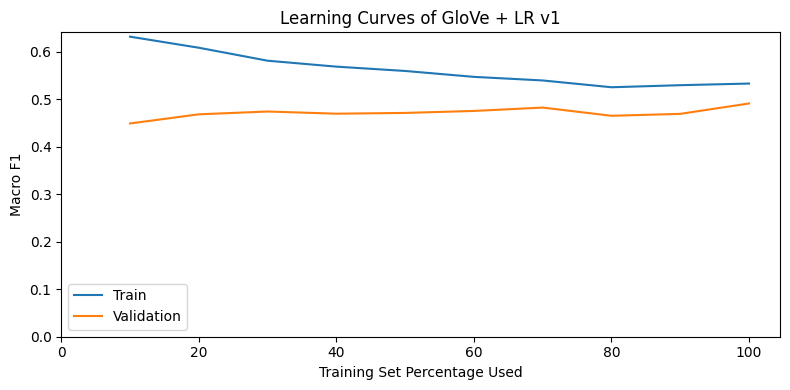

In [95]:
# Learning curves for viisual inspection
clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
plot_learning_curves(clf, X_train_w2v_v1, y_train, X_val_w2v_v1, y_val, f"Learning Curves of {best_emb_name} + LR v1")

**GloVe + LR (v1):** GloVe slightly outperforms Word2Vec with class balancing. The learning curves show a small but stable gap with both curves converging.

In [96]:
# Save TF-IDF + LR (v1) results
report_val_tfidf_v1 = classification_report(y_val, y_pred_val_tfidf_v1, output_dict=True)
results.append({
    "model": "TF-IDF + LR",
    "version": "balanced+TF-IDF tuning",
    "val_accuracy": round(report_val_tfidf_v1["accuracy"], 2),
    "val_precision": round(report_val_tfidf_v1["macro avg"]["precision"], 2),
    "val_recall": round(report_val_tfidf_v1["macro avg"]["recall"], 2),
    "val_f1": round(report_val_tfidf_v1["macro avg"]["f1-score"], 2)
})

# Save Word2Vec + LR (v1) results
report_val_w2v_v1 = classification_report(y_val, y_pred_val_w2v_v1, output_dict=True)
results.append({
    "model": "Word2Vec + LR",
    "version": f"balanced+{best_emb_name}",
    "val_accuracy": round(report_val_w2v_v1["accuracy"], 2),
    "val_precision": round(report_val_w2v_v1["macro avg"]["precision"], 2),
    "val_recall": round(report_val_w2v_v1["macro avg"]["recall"], 2),
    "val_f1": round(report_val_w2v_v1["macro avg"]["f1-score"], 2)
})

In [97]:
# Display results of (v1)
display(pd.DataFrame(results))

,model,version,val_accuracy,val_precision,val_recall,val_f1
0,TF-IDF + LR,default,0.61,0.51,0.39,0.38
1,Word2Vec + LR,default,0.61,0.57,0.39,0.36
2,TF-IDF + LR,balanced+TF-IDF tuning,0.57,0.52,0.57,0.54
3,Word2Vec + LR,balanced+GloVe,0.54,0.48,0.53,0.49


Both models improve their F1 scores significantly over their baselines.


### v2. Hyperparameter Tuning   

We systematically search over key hyperparameters and we evaluate each combination directly on the our fixed validation set to find the optimal configuration.

#### TF-IDF + LR (v2)   

In [98]:
# Traditional search over C, solver and penalty on fixed val set to find optimal LR configuration
C_values = [0.01, 0.1, 1, 10, 50, 100]
solvers = ["lbfgs", "liblinear"]
penalties = ["l1", "l2"]

best_f1 = 0
best_params = {}

for C in C_values:
  for solver in solvers:
    for penalty in penalties:
      # l1 only works with liblinear solver
      if penalty == "l1" and solver != "liblinear":
        continue
      lr_temp = LogisticRegression(C=C, solver=solver, penalty=penalty, max_iter=1000, random_state=SEED, class_weight="balanced")
      lr_temp.fit(X_train_tfidf_v1, y_train)
      f1 = f1_score(y_val, lr_temp.predict(X_val_tfidf_v1), average="macro")
      if f1 > best_f1:
        best_f1 = f1
        best_params = {"C": C, "solver": solver, "penalty": penalty}

print("Best params:", best_params)
print("Best val F1:", round(best_f1, 3))

Best params: {'C': 1, 'solver': 'liblinear', 'penalty': 'l2'}
Best val F1: 0.553


A smaller `C` applies stronger regularization, penalizing complex decision boundaries, and reducing the risk of overfitting, while a larger `C` relaxes regularization allowing the model to fit the training data more closely at the risk of memorizing noise. Given that, TF-IDF v1 that shows an overfitting gap in its learning curves, so we would expect a smaller `C` to perform best for TF-IDF (while for Word2Vec, where both curves are close and table, a larger `C` could help better).

Despite trying both L1 and L2 regularization across a wide range of C values, GridSearch consistently selects C=10, indicating that stronger regularization hurts minority class detection more than it helps reduce overfitting. The persistent train/val gap is probably a limitation of high-dimensional TF-IDF features on a small dataset.

In [99]:
# Train best model from hyperparameter search on train set
lr_tfidf_v2 = LogisticRegression(C=best_params["C"], solver=best_params["solver"], penalty=best_params["penalty"], max_iter=1000, random_state=SEED, class_weight="balanced")
lr_tfidf_v2.fit(X_train_tfidf_v1, y_train)

# Evaluate on train set
y_pred_train_tfidf_v2 = lr_tfidf_v2.predict(X_train_tfidf_v1)
accuracy_count(y_train, y_pred_train_tfidf_v2, "train")

# Evaluate on val set
y_pred_val_tfidf_v2 = lr_tfidf_v2.predict(X_val_tfidf_v1)
accuracy_count(y_val, y_pred_val_tfidf_v2, "val")

# Classification report with detailed metrics
print(classification_report(y_val, y_pred_val_tfidf_v2))

Train Accurracy: 2343/2930 (79.97%)
Val Accurracy: 332/518 (64.09%)
                 precision    recall  f1-score   support

     Ambivalent       0.68      0.84      0.75       306
Clear Non-Reply       0.54      0.48      0.51        54
    Clear Reply       0.55      0.32      0.40       158

       accuracy                           0.64       518
      macro avg       0.59      0.54      0.55       518
   weighted avg       0.62      0.64      0.62       518



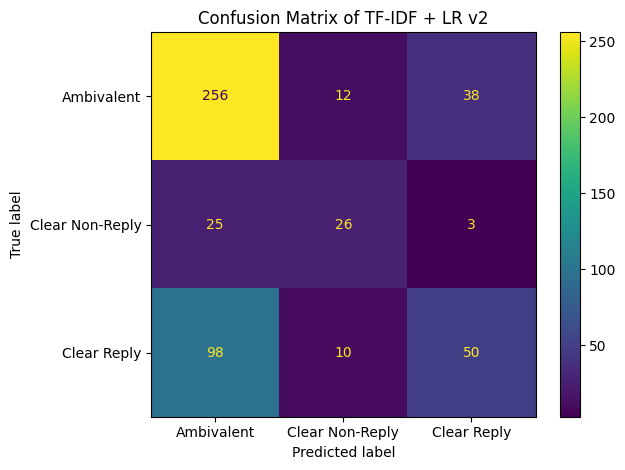

In [100]:
# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_tfidf_v2)
plt.title("Confusion Matrix of TF-IDF + LR v2")
plt.tight_layout()
plt.savefig("confusion_matrix_v2_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

1/10 | Train F1: 0.91 | Val F1: 0.32 | size: 293
2/10 | Train F1: 0.90 | Val F1: 0.36 | size: 586
3/10 | Train F1: 0.87 | Val F1: 0.42 | size: 879
4/10 | Train F1: 0.83 | Val F1: 0.50 | size: 1172
5/10 | Train F1: 0.82 | Val F1: 0.48 | size: 1465
6/10 | Train F1: 0.82 | Val F1: 0.50 | size: 1758
7/10 | Train F1: 0.79 | Val F1: 0.52 | size: 2051
8/10 | Train F1: 0.79 | Val F1: 0.51 | size: 2344
9/10 | Train F1: 0.78 | Val F1: 0.52 | size: 2637
10/10 | Train F1: 0.77 | Val F1: 0.55 | size: 2930


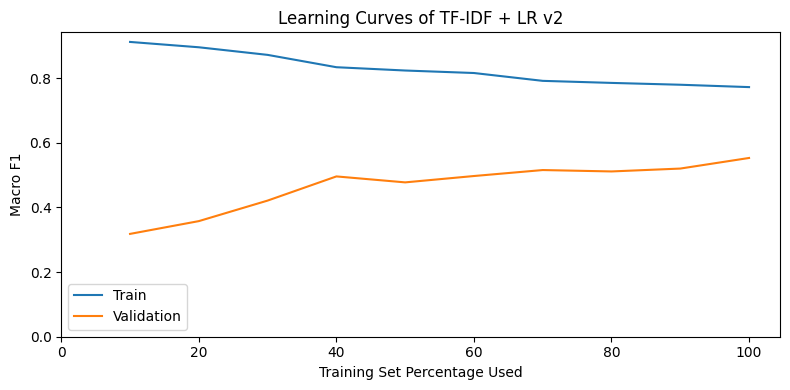

In [101]:
# Learning curves
plot_learning_curves(lr_tfidf_v2, X_train_tfidf_v1, y_train, X_val_tfidf_v1, y_val, "Learning Curves of TF-IDF + LR v2")

**TF-IDF + LR (v2):** Slight improvement with similar performance across all three classes like in (v1). The learning curves reveal a persistent gap as train F1 remains higher than validation one.

#### Word2Vec + LR (v2)

In [102]:
# Traditional search over C, solver and penalty on fixed val set to find optimal LR configuration
best_f1_w2v = 0
best_params_w2v = {}

for C in C_values:
  for solver in solvers:
    for penalty in penalties:
      # l1 only works with liblinear solver
      if penalty == "l1" and solver != "liblinear":
        continue
      lr_temp = LogisticRegression(C=C, solver=solver, penalty=penalty, max_iter=1000, random_state=SEED, class_weight="balanced")
      lr_temp.fit(X_train_w2v_v1, y_train)
      f1 = f1_score(y_val, lr_temp.predict(X_val_w2v_v1), average="macro")
      if f1 > best_f1_w2v:
        best_f1_w2v = f1
        best_params_w2v = {"C": C, "solver": solver, "penalty": penalty}

print("Best params:", best_params_w2v)
print("Best val F1:", round(best_f1_w2v, 3))

Best params: {'C': 1, 'solver': 'lbfgs', 'penalty': 'l2'}
Best val F1: 0.491


In [103]:
# Train best model from hyperparameter search on train set
lr_w2v_v2 = LogisticRegression(C=best_params_w2v["C"], solver=best_params_w2v["solver"], penalty=best_params_w2v["penalty"], max_iter=1000, random_state=SEED, class_weight="balanced")
lr_w2v_v2.fit(X_train_w2v_v1, y_train)

# Evaluate on train set
y_pred_train_w2v_v2 = lr_w2v_v2.predict(X_train_w2v_v1)
accuracy_count(y_train, y_pred_train_w2v_v2, "train")

# Evaluate on val set
y_pred_val_w2v_v2 = lr_w2v_v2.predict(X_val_w2v_v1)
accuracy_count(y_val, y_pred_val_w2v_v2, "val")

# Classification report with detailed metrics
print(classification_report(y_val, y_pred_val_w2v_v2))

Train Accurracy: 1669/2930 (56.96%)
Val Accurracy: 278/518 (53.67%)
                 precision    recall  f1-score   support

     Ambivalent       0.68      0.59      0.63       306
Clear Non-Reply       0.33      0.59      0.43        54
    Clear Reply       0.42      0.41      0.42       158

       accuracy                           0.54       518
      macro avg       0.48      0.53      0.49       518
   weighted avg       0.56      0.54      0.54       518



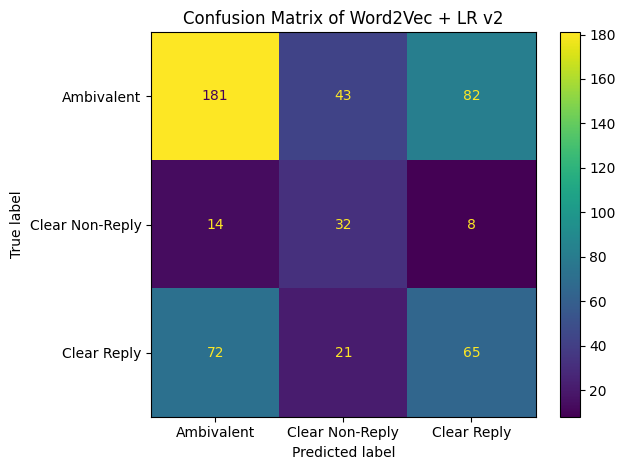

In [104]:
# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_w2v_v2)
plt.title("Confusion Matrix of Word2Vec + LR v2")
plt.tight_layout()
plt.savefig("confusion_matrix_v2_w2v.png", dpi=150, bbox_inches="tight")
plt.show()

1/10 | Train F1: 0.63 | Val F1: 0.45 | size: 293
2/10 | Train F1: 0.61 | Val F1: 0.47 | size: 586
3/10 | Train F1: 0.58 | Val F1: 0.47 | size: 879
4/10 | Train F1: 0.57 | Val F1: 0.47 | size: 1172
5/10 | Train F1: 0.56 | Val F1: 0.47 | size: 1465
6/10 | Train F1: 0.55 | Val F1: 0.48 | size: 1758
7/10 | Train F1: 0.54 | Val F1: 0.48 | size: 2051
8/10 | Train F1: 0.53 | Val F1: 0.47 | size: 2344
9/10 | Train F1: 0.53 | Val F1: 0.47 | size: 2637
10/10 | Train F1: 0.53 | Val F1: 0.49 | size: 2930


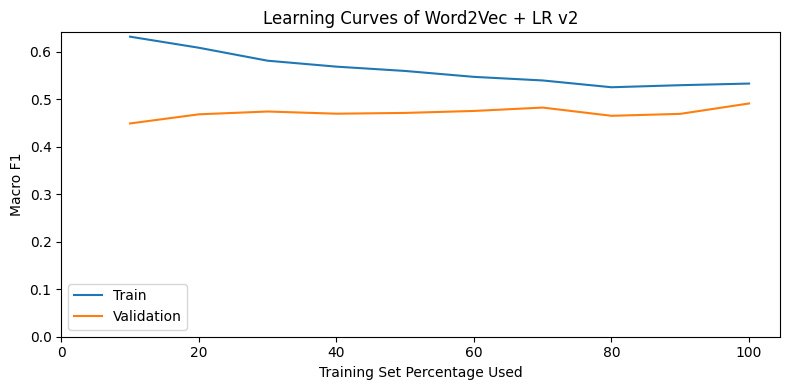

In [105]:
# Learning curves
plot_learning_curves(lr_w2v_v2, X_train_w2v_v1, y_train, X_val_w2v_v1, y_val, "Learning Curves of Word2Vec + LR v2")

**Word2Vec + LR (v2):** We  observed more balanced predictions across all three classes. The learning curves show the gap narrowing as training size increases. Train F1 steadily decreases while validation F1 rises, a healthy convergence pattern.

In [106]:
# Save TF-IDF + LR (v2) results
report_val_tfidf_v2 = classification_report(y_val, y_pred_val_tfidf_v2, output_dict=True)
results.append({
    "model": "TF-IDF + LR",
    "version": "finetuned",
    "val_accuracy": round(report_val_tfidf_v2["accuracy"], 2),
    "val_precision": round(report_val_tfidf_v2["macro avg"]["precision"], 2),
    "val_recall": round(report_val_tfidf_v2["macro avg"]["recall"], 2),
    "val_f1": round(report_val_tfidf_v2["macro avg"]["f1-score"], 2)
})

# Save Word2Vec + LR (v2) results
report_val_w2v_v2 = classification_report(y_val, y_pred_val_w2v_v2, output_dict=True)
results.append({
    "model": "Word2Vec + LR",
    "version": f"finetuned +{best_emb_name}",
    "val_accuracy": round(report_val_w2v_v2["accuracy"], 2),
    "val_precision": round(report_val_w2v_v2["macro avg"]["precision"], 2),
    "val_recall": round(report_val_w2v_v2["macro avg"]["recall"], 2),
    "val_f1": round(report_val_w2v_v2["macro avg"]["f1-score"], 2)
})

In [107]:
# Display results of (v2)
display(pd.DataFrame(results))

,model,version,val_accuracy,val_precision,val_recall,val_f1
0,TF-IDF + LR,default,0.61,0.51,0.39,0.38
1,Word2Vec + LR,default,0.61,0.57,0.39,0.36
2,TF-IDF + LR,balanced+TF-IDF tuning,0.57,0.52,0.57,0.54
3,Word2Vec + LR,balanced+GloVe,0.54,0.48,0.53,0.49
4,TF-IDF + LR,finetuned,0.64,0.59,0.54,0.55
5,Word2Vec + LR,finetuned +GloVe,0.54,0.48,0.53,0.49


Hyperparameter tuning shows no significant improvement:

- **TF-IDF + LR**: F1 0.62 → 0.63
- **Word2Vec + LR**: F1 0.47 → 0.49

### v3. TF-IDF Hyperparameter Tuning using Joint Grid Search

In [108]:
# TF-IDF + LR: joint search over vectorizer + classifier params on fixed val set custom pipeline
ngram_values = [(1, 1), (1, 2), (1, 3)]
sublinear_values = [True] # False is excluded as in all trials, we get True
min_df_values = [1, 2]
max_df_values = [0.90, 0.95, 1.0]

best_f1_v3 = 0
best_params_v3 = {}

combinations = list(product(ngram_values, sublinear_values, min_df_values, max_df_values, C_values, solvers))

for ngram, sublinear, min_df, max_df, C, solver in tqdm(combinations):
  tfidf_temp = TfidfVectorizer(ngram_range=ngram, sublinear_tf=sublinear, min_df=min_df, max_df=max_df)
  X_tr = tfidf_temp.fit_transform(X_train)
  X_vl = tfidf_temp.transform(X_val)

  lr_temp = LogisticRegression(C=C, solver=solver, max_iter=1000, random_state=SEED, class_weight="balanced")
  lr_temp.fit(X_tr, y_train)
  f1 = f1_score(y_val, lr_temp.predict(X_vl), average="macro")

  if f1 > best_f1_v3:
    best_f1_v3 = f1
    best_params_v3 = {"ngram_range": ngram, "sublinear_tf": sublinear, "min_df": min_df, "max_df": max_df, "C": C, "solver": solver}

print("Best params:", best_params_v3)
print("Best val F1:", round(best_f1_v3, 3))

100%|██████████| 216/216 [23:01<00:00,  6.40s/it]

Best params: {'ngram_range': (1, 2), 'sublinear_tf': True, 'min_df': 1, 'max_df': 1.0, 'C': 1, 'solver': 'lbfgs'}
Best val F1: 0.562


In [109]:
# Train best model from joint search on train set only
tfidf_v3 = TfidfVectorizer(ngram_range=best_params_v3["ngram_range"], sublinear_tf=best_params_v3["sublinear_tf"], min_df=best_params_v3["min_df"])

X_train_tfidf_v3 = tfidf_v3.fit_transform(X_train)
print(f"Vocabulary size with best params {best_params_v3['ngram_range']}: {tfidf_v3.get_feature_names_out().shape[0]}")
X_val_tfidf_v3 = tfidf_v3.transform(X_val)

lr_tfidf_v3 = LogisticRegression(C=best_params_v3["C"], solver=best_params_v3["solver"], max_iter=1000, random_state=SEED, class_weight="balanced")
lr_tfidf_v3.fit(X_train_tfidf_v3, y_train)

# Evaluate on train set
y_pred_train_tfidf_v3 = lr_tfidf_v3.predict(X_train_tfidf_v3)
accuracy_count(y_train, y_pred_train_tfidf_v3, "train")

# Evaluate on val set
y_pred_val_tfidf_v3 = lr_tfidf_v3.predict(X_val_tfidf_v3)
accuracy_count(y_val, y_pred_val_tfidf_v3, "val")

# Classification report with detailed metrics
print(classification_report(y_val, y_pred_val_tfidf_v3))

Vocabulary size with best params (1, 2): 165182
Train Accurracy: 2554/2930 (87.17%)
Val Accurracy: 317/518 (61.20%)
                 precision    recall  f1-score   support

     Ambivalent       0.70      0.69      0.70       306
Clear Non-Reply       0.47      0.54      0.50        54
    Clear Reply       0.50      0.49      0.49       158

       accuracy                           0.61       518
      macro avg       0.56      0.57      0.56       518
   weighted avg       0.61      0.61      0.61       518



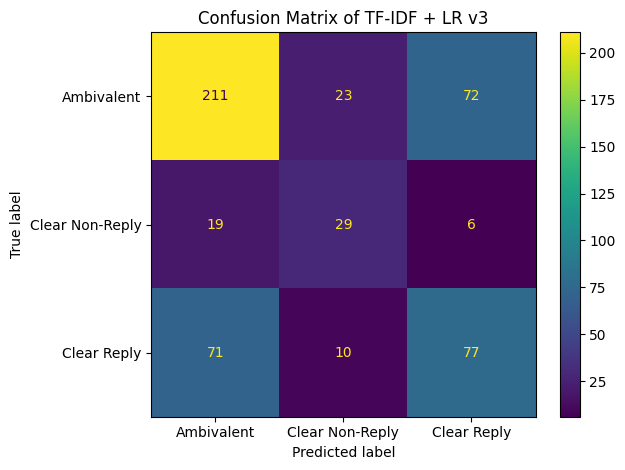

In [110]:
# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_tfidf_v3)
plt.title("Confusion Matrix of TF-IDF + LR v3")
plt.tight_layout()
plt.savefig("confusion_matrix_v3_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

1/10 | Train F1: 0.96 | Val F1: 0.33 | size: 293
2/10 | Train F1: 0.97 | Val F1: 0.41 | size: 586
3/10 | Train F1: 0.95 | Val F1: 0.45 | size: 879
4/10 | Train F1: 0.93 | Val F1: 0.49 | size: 1172
5/10 | Train F1: 0.92 | Val F1: 0.50 | size: 1465
6/10 | Train F1: 0.91 | Val F1: 0.52 | size: 1758
7/10 | Train F1: 0.90 | Val F1: 0.51 | size: 2051
8/10 | Train F1: 0.89 | Val F1: 0.53 | size: 2344
9/10 | Train F1: 0.88 | Val F1: 0.54 | size: 2637
10/10 | Train F1: 0.87 | Val F1: 0.56 | size: 2930


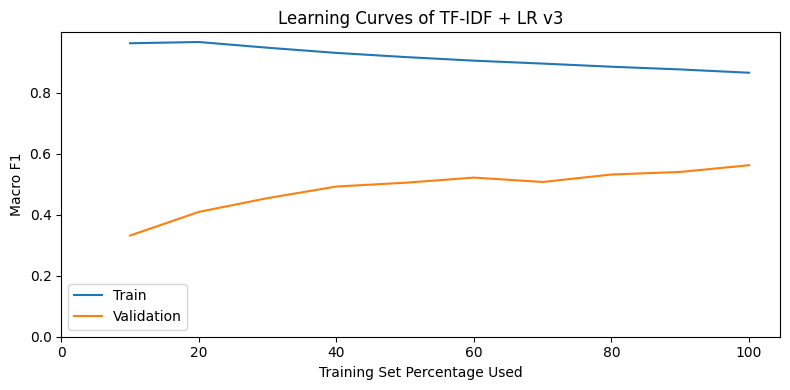

In [111]:
# Learning curves
plot_learning_curves(lr_tfidf_v3, X_train_tfidf_v3, y_train, X_val_tfidf_v3, y_val, "Learning Curves of TF-IDF + LR v3")

In [112]:
# Save TF-IDF + LR (v3) results
report_val_tfidf_v3 = classification_report(y_val, y_pred_val_tfidf_v3, output_dict=True)
results.append({
    "model": "TF-IDF + LR",
    "version": "pipeline+jointsearch",
    "val_accuracy": round(report_val_tfidf_v3["accuracy"], 2),
    "val_precision": round(report_val_tfidf_v3["macro avg"]["precision"], 2),
    "val_recall": round(report_val_tfidf_v3["macro avg"]["recall"], 2),
    "val_f1": round(report_val_tfidf_v3["macro avg"]["f1-score"], 2)
})

In [113]:
# Display the final results (v3)
display(pd.DataFrame(results))

,model,version,val_accuracy,val_precision,val_recall,val_f1
0,TF-IDF + LR,default,0.61,0.51,0.39,0.38
1,Word2Vec + LR,default,0.61,0.57,0.39,0.36
2,TF-IDF + LR,balanced+TF-IDF tuning,0.57,0.52,0.57,0.54
3,Word2Vec + LR,balanced+GloVe,0.54,0.48,0.53,0.49
4,TF-IDF + LR,finetuned,0.64,0.59,0.54,0.55
5,Word2Vec + LR,finetuned +GloVe,0.54,0.48,0.53,0.49
6,TF-IDF + LR,pipeline+jointsearch,0.61,0.56,0.57,0.56


Joint search over vectorizer and classifier hyperparameters (v3) achieved only a marginal gain in precision while maintaining the same F1.

In [143]:
# Download all generated images
# import zipfile
# import os
# from google.colab import files

# with zipfile.ZipFile("figures.zip", "w") as zipf:
#   for f in os.listdir("."):
#     if f.endswith(".png"):
#       zipf.write(f)

# files.download("figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Make Predictions on the Test set

In [114]:
# Apply v2 model to the test set
# X_test_tfidf_v2 = tfidf_v1.transform(X_test)  # v2 uses tfidf_v1 vectorizer
# y_pred_test = lr_tfidf_v2.predict(X_test_tfidf_v2)

In [115]:
# Apply best v3 model to the test set
X_test_tfidf_v3 = tfidf_v3.transform(X_test)
y_pred_test = lr_tfidf_v3.predict(X_test_tfidf_v3)

In [116]:
# Inspect some predictions
# print(y_pred_test[:5])

## Generate submission.csv

In [117]:
# Build submission dataframe matching sample_solution.csv format
submission = pd.DataFrame({
    "Id": test_df.index,
    "Predicted": y_pred_test
})

submission.to_csv("submission.csv", index=False)
print(submission.head())

   Id    Predicted
0   0  Clear Reply
1   1   Ambivalent
2   2   Ambivalent
3   3   Ambivalent
4   4   Ambivalent


## Appendix

### Adding Answer Length as an Extra Feature

In [118]:
# Answer length as extra feature alongside TF-IDF v3
# Extract answer length from raw text (before preprocessing)
ans_len_train = X_train.str.split().str.len().values.reshape(-1, 1) # (n,) -> (n, 1)
ans_len_val = X_val.str.split().str.len().values.reshape(-1, 1)

# Append length feature to TF-IDF v3 sparse matrix
X_train_tfidf_len = scipy.sparse.hstack([X_train_tfidf_v3, ans_len_train])
X_val_tfidf_len = scipy.sparse.hstack([X_val_tfidf_v3, ans_len_val])

In [119]:
# Notice how adding one extra feature (answer length) increases the number of columns by exactly 1
print(f"Shapes Before: Train: {X_train_tfidf_v3.shape} | Val: {X_val_tfidf_v3.shape}")
print(f"Shapes After: Train: {X_train_tfidf_len.shape} | Val: {X_val_tfidf_len.shape}")

Shapes Before: Train: (2930, 165182) | Val: (518, 165182)
Shapes After: Train: (2930, 165183) | Val: (518, 165183)


In [120]:
# Train same LR configuration as v3
lr_len = LogisticRegression(C=best_params_v3["C"], solver=best_params_v3["solver"], max_iter=1000, random_state=SEED, class_weight="balanced")
lr_len.fit(X_train_tfidf_len, y_train)

# Compare
f1_v3 = f1_score(y_val, y_pred_val_tfidf_v3, average="macro")
f1_len = f1_score(y_val, lr_len.predict(X_val_tfidf_len), average="macro")

print(f"TF-IDF v3 (no length): {f1_v3:.3f}")
print(f"TF-IDF v3 + answer length: {f1_len:.3f}")

TF-IDF v3 (no length): 0.562
TF-IDF v3 + answer length: 0.547


### Trying Scikit-learn Stopword Removal   

In [121]:
# TF-IDF with stopword removal and same settings as v1
tfidf_nostop = TfidfVectorizer(max_features=best_max_features, ngram_range=best_ngram, sublinear_tf=best_cfg["sublinear_tf"], min_df=best_cfg["min_df"], max_df=best_cfg["max_df"], stop_words="english")
X_train_nostop = tfidf_nostop.fit_transform(X_train)
X_val_nostop = tfidf_nostop.transform(X_val)

In [122]:
# Inspect a sample with tokens removed by stopword filtering
sample = "i think that we should not be able to answer this question clearly"

# Tokenize with and without stopwords using the fitted vectorizer
tokens_all = sample.split()
tokens_kept = [w for w in tokens_all if w in tfidf_nostop.vocabulary_]
tokens_removed = [w for w in tokens_all if w not in tfidf_nostop.vocabulary_]

print(f"Original: {tokens_all}")
print(f"Kept: {tokens_kept}")
print(f"Removed: {tokens_removed}")

Original: ['i', 'think', 'that', 'we', 'should', 'not', 'be', 'able', 'to', 'answer', 'this', 'question', 'clearly']
Kept: ['think', 'able', 'answer', 'question', 'clearly']
Removed: ['i', 'that', 'we', 'should', 'not', 'be', 'to', 'this']


In [123]:
# Train a new LR and compare with TF-IDF + LR v1
lr_nostop = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_nostop.fit(X_train_nostop, y_train)
y_pred_nostop = lr_nostop.predict(X_val_nostop)

f1_with = f1_score(y_val, y_pred_val_tfidf_v1, average="macro")
f1_without = f1_score(y_val, y_pred_nostop, average="macro")

print(f"With stopwords: {f1_with:.3f}")
print(f"Without stopwords: {f1_without:.3f}")

With stopwords: 0.537
Without stopwords: 0.533


In [124]:
# Word2Vec with stopword removal and same settings as v1
def average_w2v_nostop(text: str) -> np.ndarray:
  """
  Average Word2Vec vectors excluding stopwords.

  Args: text: preprocessed string
  Returns: 300-dim averaged vector, zeros if no words found
  """
  words = [w for w in text.split() if w not in ENGLISH_STOP_WORDS]
  vectors = [w2v_model[w] for w in words if w in w2v_model]
  if vectors:
    return np.mean(vectors, axis=0)
  return np.zeros(w2v_model.vector_size)

X_train_w2v_nostop = np.array([average_w2v_nostop(t) for t in X_train])
X_val_w2v_nostop = np.array([average_w2v_nostop(t) for t in X_val])

lr_w2v_nostop = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_w2v_nostop.fit(X_train_w2v_nostop, y_train)
y_pred_w2v_nostop = lr_w2v_nostop.predict(X_val_w2v_nostop)

f1_with = f1_score(y_val, y_pred_val_w2v_v1, average="macro")
f1_without = f1_score(y_val, y_pred_w2v_nostop, average="macro")

print(f"Word2Vec with stopwords: {f1_with:.3f}")
print(f"Word2Vec without stopwords: {f1_without:.3f}")

Word2Vec with stopwords: 0.491
Word2Vec without stopwords: 0.479


### Trying Custom Stopword Removal   

In [125]:
# Custom stopword list: words dominant across ALL classes, identified via wordclouds
custom_stopwords = ["think", "people", "know", "going", "will", "want", "re", "ll", "ve", "don", "said", "say", "make", "one", "thing", "way", "time", "well"]

tfidf_custom = TfidfVectorizer(max_features=best_max_features, ngram_range=best_ngram, sublinear_tf=best_cfg["sublinear_tf"], min_df=best_cfg["min_df"], max_df=best_cfg["max_df"], stop_words=custom_stopwords)
X_train_custom = tfidf_custom.fit_transform(X_train)
X_val_custom = tfidf_custom.transform(X_val)

lr_custom = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_custom.fit(X_train_custom, y_train)
y_pred_custom  = lr_custom.predict(X_val_custom)

f1_baseline = f1_score(y_val, y_pred_val_tfidf_v1, average="macro")
f1_custom = f1_score(y_val, y_pred_custom, average="macro")

print(f"Without custom stopwords: {f1_baseline:.3f}")
print(f"With custom stopwords: {f1_custom:.3f}")

Without custom stopwords: 0.537
With custom stopwords: 0.511


In [126]:
# Get the most common words
def get_most_common_words(texts: pd.Series, n: int = 50) -> list:
  """
  Find the most frequent words across all texts.

  Args:
    texts: Series of preprocessed strings
    n: number of top words to return

  Returns: list of n most common words
  """
  all_words = " ".join(texts).split()
  return [word for word, _ in Counter(all_words).most_common(n)]

# Inspect most common words
most_common = get_most_common_words(X_train, n=50)
print(most_common)

['the', 'to', 'and', 'that', 'i', 'of', 'we', 'a', 'in', 'it', 'is', 's', 'you', 'have', 'they', 'be', 'for', 'are', 'with', 'this', 'but', 'on', 'not', 't', 'what', 're', 'as', 'going', 'there', 'so', 'think', 'our', 'do', 'people', 'about', 'was', 've', 'will', 'very', 'can', 'if', 'all', 'at', 'he', 'been', 'or', '[SEP]', 'has', 'know', 'would']


In [127]:
# Custom stopword removal based on most common words
custom_stop = get_most_common_words(X_train, n=50)

tfidf_common = TfidfVectorizer(ngram_range=best_params_v3["ngram_range"], sublinear_tf=best_params_v3["sublinear_tf"], min_df=best_params_v3["min_df"], stop_words=custom_stop)
X_tr = tfidf_common.fit_transform(X_train)
X_vl = tfidf_common.transform(X_val)

lr_common = LogisticRegression(
    C=best_params_v3["C"],
    solver=best_params_v3["solver"],
    max_iter=1000,
    random_state=SEED,
    class_weight="balanced"
)
lr_common.fit(X_tr, y_train)

f1_common = f1_score(y_val, lr_common.predict(X_vl), average="macro")
print(f"TF-IDF v3 (no stopwords): {f1_v3:.3f}")
print(f"TF-IDF (most common removed): {f1_common:.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['sep'] not in stop_words.
  warnings.warn(


TF-IDF v3 (no stopwords): 0.562
TF-IDF (most common removed): 0.541


### Effect of Scaling on GloVe Representations

In [128]:
# Fit scaler on train, apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_w2v_v1)
X_val_scaled = scaler.transform(X_val_w2v_v1)

# Simple LR settings
lr_scaled = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = lr_scaled.predict(X_val_scaled)

f1_v1 = f1_score(y_val, y_pred_val_w2v_v1, average="macro")
f1_scaled = f1_score(y_val, y_pred_scaled, average="macro")

print(f"Embedding Representation with no scaling: {f1_v1:.3f}")
print(f"Embedding Representation with scaling: {f1_scaled:.3f}")

Embedding Representation with no scaling: 0.491
Embedding Representation with scaling: 0.438


### Max Pooling vs Mean Pooling for GloVe Representations

In [129]:
# Max pooling: take max value per dimension instead of averaging
def max_pool_glove(text: str) -> np.ndarray:
  """
  Max-pool GloVe vectors across all words in text.

  Args: text: preprocessed string
  Returns: 300-dim max-pooled vector, zeros if no words found
  """
  words = text.split()
  vectors = [glove_model[w] for w in words if w in glove_model]
  if vectors:
    return np.max(vectors, axis=0)
  return np.zeros(glove_model.vector_size)

X_train_glove_max = np.array([max_pool_glove(t) for t in X_train])
X_val_glove_max = np.array([max_pool_glove(t) for t in X_val])

lr_glove_max = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_glove_max.fit(X_train_glove_max, y_train)
y_pred_glove_max = lr_glove_max.predict(X_val_glove_max)

f1_avg = f1_score(y_val, y_pred_val_w2v_v1, average="macro")
f1_max = f1_score(y_val, y_pred_glove_max, average="macro")

print(f"GloVe mean pooling (v1): {f1_avg:.3f}")
print(f"GloVe max pooling: {f1_max:.3f}")

GloVe mean pooling (v1): 0.491
GloVe max pooling: 0.403


### GridSearch with Cross-Validation vs Fixed Validation Set

In [130]:
# Define hyperparameter grid
param_grid = {
    "C": [0.1, 1, 10, 50],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [1000]
}

In [131]:
# GridSearch with StratifiedKFold for TF-IDF + LR
gs_tfidf_v2 = GridSearchCV(
    LogisticRegression(random_state=SEED, class_weight="balanced"),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring="f1_macro",
    n_jobs=-1
)
gs_tfidf_v2.fit(X_train_tfidf_v1, y_train)

# Compare: GridSearch with StratifiedKFold vs fixed val set
f1_stratified = gs_tfidf_v2.best_score_  # best CV score from StratifiedKFold
f1_fixed = best_f1 # best score from fixed val set loop (from above)

print(("TF-IDF:"))
print(f"Best params (StratifiedKFold): {gs_tfidf_v2.best_params_}")
print(f"Best CV F1 (StratifiedKFold): {f1_stratified:.3f}")
print(f"\nBest params (fixed val set): {best_params}")
print(f"Best val F1 (fixed val set): {f1_fixed:.3f}")

TF-IDF:
Best params (StratifiedKFold): {'C': 1, 'max_iter': 1000, 'solver': 'liblinear'}
Best CV F1 (StratifiedKFold): 0.510

Best params (fixed val set): {'C': 1, 'solver': 'liblinear', 'penalty': 'l2'}
Best val F1 (fixed val set): 0.553


In [132]:
# GridSearch with StratifiedKFold for GloVe + LR
gs_w2v_v2 = GridSearchCV(
    LogisticRegression(random_state=SEED, class_weight="balanced"),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring="f1_macro",
    n_jobs=-1
)
gs_w2v_v2.fit(X_train_w2v_v1, y_train)

print(("GloVe + LR:"))
print(f"Best params (StratifiedKFold): {gs_w2v_v2.best_params_}")
print(f"Best CV F1 (StratifiedKFold): {gs_w2v_v2.best_score_:.3f}")
print(f"\nBest params (fixed val set): {best_params_w2v}")
print(f"Best val F1 (fixed val set): {best_f1_w2v:.3f}")

GloVe + LR:
Best params (StratifiedKFold): {'C': 10, 'max_iter': 1000, 'solver': 'liblinear'}
Best CV F1 (StratifiedKFold): 0.457

Best params (fixed val set): {'C': 1, 'solver': 'lbfgs', 'penalty': 'l2'}
Best val F1 (fixed val set): 0.491


### Trying alternative Classifiers   

In [133]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier, RidgeClassifier
from sklearn.svm import LinearSVC, SVC

classifiers = {
    "Random Forest": RandomForestClassifier(random_state=SEED, class_weight="balanced"),
    "SGD Classifier": SGDClassifier(random_state=SEED, class_weight="balanced"),
    "Ridge Classifier": RidgeClassifier(class_weight="balanced"),
    "Linear SVM": LinearSVC(random_state=SEED, class_weight="balanced"),
    # "SVM": SVC(random_state=SEED, class_weight="balanced") # kernel="rbf"
}

In [136]:
# Try on TF-IDF v3 features
f1_lr = f1_score(y_val, y_pred_val_tfidf_v3, average="macro")
print("TF-IDF:")
print(f"Logistic Regression (v3): {f1_lr:.3f}")

for name, clf in classifiers.items():
  clf.fit(X_train_tfidf_v3, y_train)
  y_pred = clf.predict(X_val_tfidf_v3)
  f1 = f1_score(y_val, y_pred, average="macro")
  print(f"{name}: {f1:.3f}")

TF-IDF:
Logistic Regression (v3): 0.562
Random Forest: 0.499
SGD Classifier: 0.545
Ridge Classifier: 0.566
Linear SVM: 0.550


In [135]:
# Try on best performing embedding feature-representation
f1_lr_w2v = f1_score(y_val, y_pred_val_w2v_v1, average="macro")
print("GloVe:")
print(f"Logistic Regression (v1): {f1_lr_w2v:.3f}")

for name, clf in classifiers.items():
  clf.fit(X_train_w2v_v1, y_train)
  y_pred = clf.predict(X_val_w2v_v1)
  f1 = f1_score(y_val, y_pred, average="macro")
  print(f"{name}: {f1:.3f}")

GloVe:
Logistic Regression (v1): 0.491
Random Forest: 0.354
SGD Classifier: 0.491
Ridge Classifier: 0.486
Linear SVM: 0.495
